Link to Google Drive with full datasets: https://drive.google.com/drive/folders/1nQWf6tNgxnU6hIeuOHjCJ_2SvBHEXIVR?usp=sharing

In [33]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from functools import reduce
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from IPython.display import Markdown, display
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
# Configure global display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_seq_items', None)
pd.set_option('display.width', None)

In [35]:
# Import data from Google Drive
path = '/content/drive/My Drive/DS Capstone/Data'

T100 = pd.read_csv(path + '/T100-Merged.csv', low_memory=False)
F41 = pd.read_csv(path + '/F41_1.2-Merged.csv')
otp_raw = pd.read_csv(path + '/OTP_Kaggle.csv')

print("T100 shape:", T100.shape)
print("F41 shape: ", F41.shape)
print("OTP shape: ", otp_raw.shape)
print("\nOTP columns:", otp_raw.columns.tolist())
print("OTP years:  ", sorted(otp_raw['year'].unique()))

T100 shape: (2193983, 38)
F41 shape:  (3678, 53)
OTP shape:  (398233, 21)

OTP columns: ['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name', 'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted', 'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
OTP years:   [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


## Data Cleaning/Munging

#### T100 Data

In [36]:
t100 = T100.copy()

# Fix null unique carrier values
t100.loc[t100['UNIQUE_CARRIER'].isna(), 'UNIQUE_CARRIER'] = t100['CARRIER']

# Fix naming conventions
t100['UNIQUE_CARRIER'] = t100['UNIQUE_CARRIER'].str.replace(r'\s*\(\d+\)$', '', regex=True)

# Create a unique route identifier
t100['route_key'] = (
    t100['ORIGIN_AIRPORT_ID'].astype(str) + "_" +
    t100['DEST_AIRPORT_ID'].astype(str)
)

# Create match key
t100['Match Key'] = (
    t100['UNIQUE_CARRIER'].astype(str)
    + '-' + t100['YEAR'].astype(str)
    + 'Q' + t100['QUARTER'].astype(str)
)

# Define numeric columns for t100
t100_numeric_cols = [
    'PASSENGERS', 'FREIGHT', 'MAIL', 'DISTANCE', 'DISTANCE_GROUP',
    'ORIGIN_AIRPORT_ID',     'DEST_AIRPORT_ID',
    'ORIGIN_CITY_MARKET_ID', 'DEST_CITY_MARKET_ID',
]
# Convert columns to numeric for t100
for col in t100_numeric_cols:
    if col in t100.columns:
        t100[col] = pd.to_numeric(t100[col], errors='coerce')

t100_agg = (
    t100.groupby('Match Key', as_index=False)
    .agg({
        'PASSENGERS':               'sum',
        'FREIGHT':                  'sum',
        'MAIL':                     'sum',
        'DISTANCE':                 'sum',

        'UNIQUE_CARRIER':           'first',
        'UNIQUE_CARRIER_NAME':      'first',
        'YEAR':                     'first',
        'QUARTER':                  'first',
        'MONTH':                    'nunique',

        'CARRIER_GROUP_NEW':        'first',
        'DISTANCE_GROUP':           'mean',
        'REGION':                   'nunique',
        'ORIGIN_AIRPORT_ID':        'nunique',
        'DEST_AIRPORT_ID':          'nunique',
        'ORIGIN_CITY_MARKET_ID':    'nunique',
        'DEST_CITY_MARKET_ID':      'nunique',
        'route_key':                'nunique'
    })
    .rename(columns={
        'FREIGHT':               'FREIGHT_LBS',
        'MAIL':                  'MAIL_LBS',
        'DISTANCE':              'DISTANCE_MI',
        'MONTH':                 'MONTH_CT',
        'DISTANCE_GROUP':        'DISTANCE_GROUP_AVG',
        'REGION':                'REGION_CT',
        'ORIGIN_AIRPORT_ID':     'ORIGIN_AIRPORT_ID_CT',
        'DEST_AIRPORT_ID':       'DEST_AIRPORT_ID_CT',
        'ORIGIN_CITY_MARKET_ID': 'ORIGIN_CITY_MARKET_ID_CT',
        'DEST_CITY_MARKET_ID':   'DEST_CITY_MARKET_ID_CT',
        'route_key':             'route_count'
    })
)

print("t100_agg shape:", t100_agg.shape)
t100_agg.head()

t100_agg shape: (4440, 18)


,Match Key,PASSENGERS,FREIGHT_LBS,MAIL_LBS,DISTANCE_MI,UNIQUE_CARRIER,UNIQUE_CARRIER_NAME,YEAR,QUARTER,MONTH_CT,CARRIER_GROUP_NEW,DISTANCE_GROUP_AVG,REGION_CT,ORIGIN_AIRPORT_ID_CT,DEST_AIRPORT_ID_CT,ORIGIN_CITY_MARKET_ID_CT,DEST_CITY_MARKET_ID_CT,route_count
0,02Q-2022Q4,51,0,0,2606,02Q,Titan Airways,2022,4,1,0.0,3.0,1,2,2,2,2,2
1,02Q-2023Q1,54,0,0,1425,02Q,Titan Airways,2023,1,1,0.0,3.0,1,1,1,1,1,1
2,02Q-2023Q4,7,0,0,1402,02Q,Titan Airways,2023,4,1,0.0,3.0,1,1,1,1,1,1
3,02Q-2024Q1,44,0,0,3928,02Q,Titan Airways,2024,1,1,0.0,8.0,1,1,1,1,1,1
4,02Q-2024Q2,43,0,0,1446,02Q,Titan Airways,2024,2,2,0.0,2.0,1,2,2,2,2,2


#### F41-1.2 Financial Data

In [37]:
f41  = F41.copy()

# Rename MAIL (revenue) to distinguish from MAIL (pounds) in t100
f41 = f41.rename(columns={'MAIL': 'MAIL_REV'})

# Fix null unique carrier values
f41.loc[f41['UNIQUE_CARRIER'].isna(), 'UNIQUE_CARRIER'] = f41['CARRIER']

# Fix naming conventions
f41['UNIQUE_CARRIER'] = f41['UNIQUE_CARRIER'].str.replace(r'\s*\(\d+\)$', '', regex=True)

# Create match key
f41['Match Key'] = (
    f41['UNIQUE_CARRIER'].astype(str)
    + '-' + f41['YEAR'].astype(str)
    + 'Q' + f41['QUARTER'].astype(str)
)

# Define numeric columns for f41
f41_numeric_cols = [
    'NET_INCOME',       'OP_PROFIT_LOSS',  'TRANS_REV_PAX',      'MAIL_REV',
    'TOTAL_PROPERTY',   'PROP_FREIGHT',    'PROP_BAG',           'TOTAL_CHARTER',
    'CHARTER_PAX',      'CHARTER_PROP',    'TOTAL_MISC_REV',     'RES_CANCEL_FEES',
    'MISC_OP_REV',      'PUB_SVC_REVENUE', 'TRANS_REVENUE',      'OP_REVENUES',
    'FLYING_OPS',       'MAINTENANCE',     'PAX_SERVICE',        'AIRCFT_SERVICES',
    'PROMOTION_SALES',  'GENERAL_ADMIN',   'GENERAL_SERVICES',   'DEPREC_AMORT',
    'TRANS_EXPENSES',   'OP_EXPENSES',     'INTEREST_LONG_DEBT', 'INTEREST_EXP_OTH',
    'FOREIGN_EX_GAINS', 'CAP_GAINS_PROP',  'CAP_GAINS_OTHER',    'OTHER_INCOME_NET',
    'NON_OP_INCOME',    'INCOME_PRE_TAX',  'INCOME_TAX',         'INCOME_BEFORE_OTH',
    'DISCONT_OPS',      'EXTRA_ITEMS',     'INCOME_TAX_EXTRA',   'INCOME_TAX_CREDITS',
    'ACCTG_CHANGES'
]
# Convert columns to numeric for f41
for col in f41_numeric_cols:
    if col in f41.columns:
        f41[col] = pd.to_numeric(f41[col], errors='coerce')

# Aggregate f41 data
f41_agg = (
    f41.groupby('Match Key', as_index=False)
    .agg({
        **{col: 'sum' for col in f41_numeric_cols},
        'UNIQUE_CARRIER':      'first',
        'UNIQUE_CARRIER_NAME': 'first',
        'YEAR':                'first',
        'QUARTER':             'first',
        'CARRIER_GROUP_NEW':   'first',
        'REGION':              'nunique'
    })
    .rename(columns={
        'REGION': 'REGION_CT'})
)

print("f41_agg shape:", f41_agg.shape)
f41_agg.head()

f41_agg shape: (1876, 48)


,Match Key,NET_INCOME,OP_PROFIT_LOSS,TRANS_REV_PAX,MAIL_REV,TOTAL_PROPERTY,PROP_FREIGHT,PROP_BAG,TOTAL_CHARTER,CHARTER_PAX,CHARTER_PROP,TOTAL_MISC_REV,RES_CANCEL_FEES,MISC_OP_REV,PUB_SVC_REVENUE,TRANS_REVENUE,OP_REVENUES,FLYING_OPS,MAINTENANCE,PAX_SERVICE,AIRCFT_SERVICES,PROMOTION_SALES,GENERAL_ADMIN,GENERAL_SERVICES,DEPREC_AMORT,TRANS_EXPENSES,OP_EXPENSES,INTEREST_LONG_DEBT,INTEREST_EXP_OTH,FOREIGN_EX_GAINS,CAP_GAINS_PROP,CAP_GAINS_OTHER,OTHER_INCOME_NET,NON_OP_INCOME,INCOME_PRE_TAX,INCOME_TAX,INCOME_BEFORE_OTH,DISCONT_OPS,EXTRA_ITEMS,INCOME_TAX_EXTRA,INCOME_TAX_CREDITS,ACCTG_CHANGES,UNIQUE_CARRIER,UNIQUE_CARRIER_NAME,YEAR,QUARTER,CARRIER_GROUP_NEW,REGION_CT
0,09Q-2016Q1,3046.58,3262.10,0.0,0.0,0.0,0.0,0.0,0.0,21131.61,29.37,0.0,0.0,193.38,0.0,0.0,21354.35,8875.04,3005.68,0.0,2293.41,0.93,3301.56,0.0,615.63,0.0,18092.26,-215.51,0.0,0.0,0.0,0.0,0.0,-215.51,3046.58,0.0,3046.58,0.0,0.0,0.0,0.0,0.0,09Q,"Swift Air, LLC d/b/a Eastern Air Lines d/b/a Eastern",2016,1,1,1
1,09Q-2016Q2,762.04,1046.31,0.0,0.0,0.0,0.0,0.0,0.0,15619.91,107.09,0.0,0.0,-109.62,0.0,0.0,15617.38,7364.89,3080.95,0.0,989.22,37.08,2280.72,0.0,818.21,0.0,14571.07,-284.27,0.0,0.0,0.0,0.0,0.0,-284.27,762.04,0.0,762.04,0.0,0.0,0.0,0.0,0.0,09Q,"Swift Air, LLC d/b/a Eastern Air Lines d/b/a Eastern",2016,2,1,1
2,09Q-2016Q3,1332.99,1615.81,0.0,0.0,0.0,0.0,0.0,0.0,17521.54,57.43,0.0,0.0,347.80,0.0,0.0,17926.77,8584.72,3592.41,0.0,971.29,1.16,2247.15,0.0,914.24,0.0,16310.96,-282.82,0.0,0.0,0.0,0.0,0.0,-282.82,1332.99,0.0,1332.99,0.0,0.0,0.0,0.0,0.0,09Q,"Swift Air, LLC d/b/a Eastern Air Lines d/b/a Eastern",2016,3,1,1
3,09Q-2016Q4,1623.98,1941.46,0.0,0.0,0.0,0.0,0.0,0.0,21918.16,21.17,0.0,0.0,682.73,0.0,0.0,22622.06,10347.75,3089.85,0.0,2143.84,9.66,4066.11,0.0,1023.39,0.0,20680.60,-317.49,0.0,0.0,0.0,0.0,0.0,-317.49,1623.98,0.0,1623.98,0.0,0.0,0.0,0.0,0.0,09Q,"Swift Air, LLC d/b/a Eastern Air Lines d/b/a Eastern",2016,4,1,1
4,09Q-2017Q1,2861.17,3234.46,0.0,0.0,0.0,0.0,0.0,0.0,23914.39,284.74,0.0,0.0,573.01,0.0,0.0,24772.14,11524.54,2888.27,0.0,2301.20,4.25,3625.09,0.0,1194.34,0.0,21537.69,-373.29,0.0,0.0,0.0,0.0,0.0,-373.29,2861.17,0.0,2861.17,0.0,0.0,0.0,0.0,0.0,09Q,"Swift Air, LLC d/b/a Eastern Air Lines d/b/a Eastern",2017,1,1,1


#### On-Time Performance Data


In [38]:
# Keep only relevant data (years 2016-2024) from the on-time performance (otp) dataset
otp = otp_raw[otp_raw['year'].between(2016, 2024)].copy()
otp = otp.reset_index(drop=True)

# Fix naming conventions in line with BTS data
name_fixes = {
    'American Airlines Network'                 : 'American Airlines Inc.',
    'Alaska Airlines Network'                   : 'Alaska Airlines Inc.',
    'Commutair Aka Champlain Enterprises, Inc.' : 'CommuteAir LLC dba CommuteAir',
    'Delta Air Lines Network'                   : 'Delta Air Lines Inc.',
    'ExpressJet Airlines Inc.'                  : 'ExpressJet Airlines LLC d/b/a aha!',
    'ExpressJet Airlines LLC'                   : 'ExpressJet Airlines LLC d/b/a aha!',
    'Frontier Airlines'                         : 'Frontier Airlines Inc.',
    'Hawaiian Airlines Network'                 : 'Hawaiian Airlines Inc.',
    'Spirit Airlines'                           : 'Spirit Air Lines',
    'United Air Lines Network'                  : 'United Air Lines Inc.',
    'Southwest Airlines'                        : 'Southwest Airlines Co.',
    'Cape Air'                                  : 'Hyannis Air Service, Inc. dba Cape Air'
}

otp['carrier_name'] = otp['carrier_name'].replace(name_fixes)

# Rename/format column names for consistency across datasets
otp['dest_city_name'] = otp['airport_name'].str.split(':').str[0]
otp['dest'] = otp['airport']

# Add a quarter column
otp['quarter'] = otp['month'].apply(
    lambda m: 1 if m<=3 else 2 if m<=6 else 3 if m<=9 else 4
)

# Create match key
otp['Match Key'] = (
    otp['carrier'].astype(str)
    + '-' + otp['year'].astype(str)
    + 'Q' + otp['quarter'].astype(str)
)

# Define numeric columns for otp
otp_num_cols = [
    'arr_flights',   'arr_del15',     'arr_cancelled', 'arr_diverted',   'arr_delay',
    'carrier_ct',    'weather_ct',    'nas_ct',        'security_ct',    'late_aircraft_ct',
    'carrier_delay', 'weather_delay', 'nas_delay',     'security_delay', 'late_aircraft_delay'
]
#Convert columns to numeric for otp
for col in otp_num_cols:
    if col in otp.columns:
        otp[col] = pd.to_numeric(otp[col], errors='coerce')

# Aggregate otp data
otp_agg = (
    otp.groupby('Match Key', as_index=False)
    .agg(
        TOTAL_FLIGHTS       = ('arr_flights',         'sum'),
        TOTAL_DELAYED       = ('arr_del15',           'sum'),
        TOTAL_CANCELLED     = ('arr_cancelled',       'sum'),
        TOTAL_DIVERTED      = ('arr_diverted',        'sum'),
        TOTAL_ARR_DELAY_MIN = ('arr_delay',           'sum'),

        CARRIER_DELAY_CT    = ('carrier_ct',          'sum'),
        WEATHER_DELAY_CT    = ('weather_ct',          'sum'),
        NAS_DELAY_CT        = ('nas_ct',              'sum'),
        SECURITY_DELAY_CT   = ('security_ct',         'sum'),
        LATE_AC_DELAY_CT    = ('late_aircraft_ct',    'sum'),

        CARRIER_DELAY_MIN   = ('carrier_delay',       'sum'),
        WEATHER_DELAY_MIN   = ('weather_delay',       'sum'),
        NAS_DELAY_MIN       = ('nas_delay',           'sum'),
        SECURITY_DELAY_MIN  = ('security_delay',      'sum'),
        LATE_AC_DELAY_MIN   = ('late_aircraft_delay', 'sum'),

        UNIQUE_CARRIER      = ('carrier',           'first'),
        UNIQUE_CARRIER_NAME = ('carrier_name',      'first'),
        YEAR                = ('year',              'first'),
        QUARTER             = ('quarter',           'first')
    )
)

print("otp_agg shape:", otp_agg.shape)
otp_agg.head()

otp_agg shape: (739, 20)


,Match Key,TOTAL_FLIGHTS,TOTAL_DELAYED,TOTAL_CANCELLED,TOTAL_DIVERTED,TOTAL_ARR_DELAY_MIN,CARRIER_DELAY_CT,WEATHER_DELAY_CT,NAS_DELAY_CT,SECURITY_DELAY_CT,LATE_AC_DELAY_CT,CARRIER_DELAY_MIN,WEATHER_DELAY_MIN,NAS_DELAY_MIN,SECURITY_DELAY_MIN,LATE_AC_DELAY_MIN,UNIQUE_CARRIER,UNIQUE_CARRIER_NAME,YEAR,QUARTER
0,9E-2018Q1,56905.0,9937.0,3057.0,120.0,775205.0,2628.66,405.71,3186.23,4.05,3712.35,242422.0,75614.0,171144.0,298.0,285727.0,9E,Endeavor Air Inc.,2018,1
1,9E-2018Q2,63977.0,11203.0,898.0,167.0,869088.0,2676.07,437.41,3900.48,3.50,4185.59,230991.0,63049.0,230690.0,157.0,344201.0,9E,Endeavor Air Inc.,2018,2
2,9E-2018Q3,63991.0,12034.0,1910.0,145.0,1025971.0,2668.39,449.30,4481.19,2.63,4432.50,225790.0,64803.0,355903.0,118.0,379357.0,9E,Endeavor Air Inc.,2018,3
3,9E-2018Q4,61185.0,10925.0,441.0,128.0,771422.0,2540.93,312.20,3800.06,6.88,4264.90,206602.0,46433.0,189783.0,490.0,328114.0,9E,Endeavor Air Inc.,2018,4
4,9E-2019Q1,60905.0,11141.0,1155.0,114.0,854341.0,2562.91,418.81,3571.40,4.08,4583.81,212032.0,63729.0,205747.0,170.0,372663.0,9E,Endeavor Air Inc.,2019,1


### Merging all 3 datasets

In [39]:
# Check key and carrier counts within each dataset
key = 'Match Key'

dfs = {
    'T100': t100_agg,
    'F41' : f41_agg,
    'OTP' : otp_agg
}

# --- Basic counts ---
print("=== BASIC COUNTS ===")
for name, df in dfs.items():
    print(f"{name}: carriers={df['UNIQUE_CARRIER'].nunique()}, keys={df[key].nunique()}")

# --- Key sets ---
key_sets = {name: set(df[key]) for name, df in dfs.items()}

t100_keys = key_sets['T100']
f41_keys  = key_sets['F41']
otp_keys  = key_sets['OTP']

# --- Overlaps ---
print("\n=== OVERLAPS ===")
print(f"T100 ∩ F41        : {len(t100_keys & f41_keys)}")
print(f"T100 ∩ OTP        : {len(t100_keys & otp_keys)}")
print(f"F41  ∩ OTP        : {len(f41_keys & otp_keys)}")
print(f"All three (inner) : {len(t100_keys & f41_keys & otp_keys)}")

# --- Unique to each dataset ---
print("\n=== UNIQUE TO EACH ===")
print(f"T100 only : {len(t100_keys - f41_keys - otp_keys)}")
print(f"F41 only  : {len(f41_keys - t100_keys - otp_keys)}")
print(f"OTP only  : {len(otp_keys - t100_keys - f41_keys)}")

# --- Merge behavior ---
left_keys  = t100_keys
inner_keys = t100_keys & f41_keys & otp_keys
outer_keys = t100_keys | f41_keys | otp_keys

print("\n=== MERGE RESULTS ===")
print(f"Left  (T100 base) : {len(left_keys)}")
print(f"Inner (all match) : {len(inner_keys)}")
print(f"Outer (union)     : {len(outer_keys)}")

# --- Left join diagnostics ---
print("\n=== LEFT JOIN (T100) DETAILS ===")
print(f"No F41 match        : {len(t100_keys - f41_keys)}")
print(f"No OTP match        : {len(t100_keys - otp_keys)}")
print(f"Missing either one  : {len(t100_keys - (f41_keys & otp_keys))}")

=== BASIC COUNTS ===
T100: carriers=246, keys=4440
F41: carriers=68, keys=1876
OTP: carriers=28, keys=739

=== OVERLAPS ===
T100 ∩ F41        : 1825
T100 ∩ OTP        : 739
F41  ∩ OTP        : 681
All three (inner) : 681

=== UNIQUE TO EACH ===
T100 only : 2557
F41 only  : 51
OTP only  : 0

=== MERGE RESULTS ===
Left  (T100 base) : 4440
Inner (all match) : 681
Outer (union)     : 4491

=== LEFT JOIN (T100) DETAILS ===
No F41 match        : 2615
No OTP match        : 3701
Missing either one  : 3759


In [40]:
# Check for mismatching values across T100 and F41
cols_to_check = [
    'QUARTER',
    'YEAR',
    'UNIQUE_CARRIER',
    'UNIQUE_CARRIER_NAME',
    'CARRIER_GROUP_NEW',
    'REGION_CT',
]

compare_df = (
    t100_agg[['Match Key'] + cols_to_check]
    .merge(
        f41_agg[['Match Key'] + cols_to_check],
        on='Match Key',
        how='inner',
        suffixes=('_T100', '_F41'),
        validate='one_to_one'
    )
)

for col in cols_to_check:
    mismatches = compare_df[
        compare_df[f'{col}_T100'] != compare_df[f'{col}_F41']
    ]
    print(f"{col}: {len(mismatches)} mismatches")

QUARTER: 0 mismatches
YEAR: 0 mismatches
UNIQUE_CARRIER: 0 mismatches
UNIQUE_CARRIER_NAME: 0 mismatches
CARRIER_GROUP_NEW: 0 mismatches
REGION_CT: 907 mismatches


In [41]:
# Define merge columns
merge_cols = [
    'Match Key',
    'UNIQUE_CARRIER',
    'UNIQUE_CARRIER_NAME',
    'YEAR',
    'QUARTER'
]

agg_list = [t100_agg.copy(), f41_agg.copy(), otp_agg.copy()]

# Merge t100_agg, f41_agg, and otp_agg
# how='left'  - Keep keys only if also present in t100
# how='inner' - Keep keys only if common across all 3 datasets
# how='outer' - Keep keys from all 3 datasets
agg_df = (
    reduce(lambda left, right: pd.merge(
        left, right,
        on=merge_cols,
        how='left',
        suffixes=('_T100', '_F41'),
        validate='one_to_one'
        ),
        agg_list)
)

print("agg_df shape:", agg_df.shape)

agg_df shape: (4440, 76)


### Adding Variables

In [42]:
# Define COVID periods
def assign_period(year):
    if pd.isna(year):
        return np.nan
    year = int(year)
    if 2016 <= year <= 2019: return 'Pre-COVID'
    elif 2020 <= year <= 2021: return 'COVID'
    elif 2022 <= year <= 2025: return 'Post-COVID'
    return 'Other'

agg_df['period'] = agg_df['YEAR'].apply(assign_period)

# Define carrier type
legacy_carriers = [
    'AA', 'AS', 'DL', 'HA', 'UA'
]
low_cost_carriers = [
    'WN', 'B6', 'F9', 'G4', 'NK', 'SY', 'VX', 'XP', 'MX'
]
cargo_carriers = [
    '5X', 'FX', '8C', 'ABX', 'AMQ', 'GFQ', 'PO', '5Y',
    '5V', 'KH', 'KAQ','KLQ', 'M6',  'NC',  'KZ', 'L2',
    'W8', 'WI', 'WE'
]
regional_carriers = [
    'OO', 'YX', 'MQ', 'OH', 'ZW', 'CP', '9E', 'YV',
    'EV', 'G7', 'PT', 'C5', 'KS', 'S5', 'K5', 'AX',
    'QX', '9K', '3E', 'ZK', '3M'
]

def classify_carrier(carrier):
    if pd.isna(carrier): return 'Unknown'
    c = str(carrier).strip()
    if c in legacy_carriers:   return 'Legacy'
    if c in low_cost_carriers: return 'Low-Cost'
    if c in cargo_carriers:    return 'Cargo'
    if c in regional_carriers: return 'Regional'
    return 'Other'

agg_df['carrier_type'] = agg_df['UNIQUE_CARRIER'].apply(classify_carrier)

In [43]:
def format_list(series):
    max_len = max(len(str(k)) for k in series.index)
    for label, value in series.items():
        dots = '.' * (max_len - len(str(label)) + 5)
        print(f"{label}{dots}{value}")
    print()

print("TOTAL OBSERVATIONS\n")
print("Carrier type counts:")
carrier_order = ['Legacy', 'Low-Cost', 'Cargo', 'Regional', 'Other']
format_list(
    agg_df.groupby('carrier_type')['Match Key']
    .nunique()
    .reindex(carrier_order)
)
print("Period counts:")
period_order = ['Pre-COVID', 'COVID', 'Post-COVID']
format_list(
    agg_df.groupby('period')['Match Key']
    .nunique()
    .reindex(period_order)
)

TOTAL OBSERVATIONS

Carrier type counts:
Legacy.......180
Low-Cost.....274
Cargo........582
Regional.....588
Other........2816

Period counts:
Pre-COVID......2003
COVID..........949
Post-COVID.....1488



In [44]:
# Monthly metrics
month_ct_nz = agg_df['MONTH_CT'].replace(0, np.nan)
agg_df['avg_passengers_per_month'] = agg_df['PASSENGERS']  / month_ct_nz
agg_df['avg_distance_per_month']   = agg_df['DISTANCE_MI'] / month_ct_nz

# Freight and mail ratios
passengers_nz = agg_df['PASSENGERS'].replace(0, np.nan)
agg_df['freight_ratio'] = agg_df['FREIGHT_LBS'] / passengers_nz
agg_df['mail_ratio']    = agg_df['MAIL_LBS']    / passengers_nz

# Passenger economies
agg_df['cost_per_passenger']    = agg_df['OP_EXPENSES'] / passengers_nz
agg_df['revenue_per_passenger'] = agg_df['OP_REVENUES'] / passengers_nz
agg_df['profit_per_passenger']  = agg_df['NET_INCOME']  / passengers_nz

# Profitability metrics
op_revenues_nz = agg_df['OP_REVENUES'].replace(0, np.nan)
agg_df['operating_margin'] = agg_df['OP_PROFIT_LOSS'] / op_revenues_nz
agg_df['net_margin']       = agg_df['NET_INCOME']     / op_revenues_nz
agg_df['op_exp_ratio']     = agg_df['OP_EXPENSES']    / op_revenues_nz

# Route metrics
route_count_nz = agg_df['route_count'].replace(0, np.nan)
agg_df['avg_passengers_per_route'] = agg_df['PASSENGERS']  / route_count_nz
agg_df['avg_distance_per_route']   = agg_df['DISTANCE_MI'] / route_count_nz
agg_df['freight_per_route']        = agg_df['FREIGHT_LBS'] / route_count_nz
agg_df['mail_per_route']           = agg_df['MAIL_LBS']    / route_count_nz
# Route financials
agg_df['cost_per_route']    = agg_df['OP_EXPENSES'] / route_count_nz
agg_df['revenue_per_route'] = agg_df['OP_REVENUES'] / route_count_nz

# Distance efficiency
distance_mi_nz = agg_df['DISTANCE_MI'].replace(0, np.nan)
agg_df['freight_per_distance']    = agg_df['FREIGHT_LBS'] / distance_mi_nz
agg_df['passengers_per_distance'] = agg_df['PASSENGERS']  / distance_mi_nz

# Network size
agg_df['network_size']  = agg_df['ORIGIN_AIRPORT_ID_CT'] + agg_df['DEST_AIRPORT_ID_CT']

# Overall on-time performance
total_flights_nz = agg_df['TOTAL_FLIGHTS'].replace(0, np.nan)
agg_df['on_time_rate']      = 1 - agg_df['TOTAL_DELAYED']   / total_flights_nz
agg_df['delay_rate']        = agg_df['TOTAL_DELAYED']       / total_flights_nz
agg_df['cancellation_rate'] = agg_df['TOTAL_CANCELLED']     / total_flights_nz
agg_df['diverted_rate']     = agg_df['TOTAL_DIVERTED']      / total_flights_nz

agg_df['avg_arr_delay_min'] = agg_df['TOTAL_ARR_DELAY_MIN'] / agg_df['TOTAL_DELAYED'].replace(0, np.nan)

total_arr_delay_min_nz = agg_df['TOTAL_ARR_DELAY_MIN'].replace(0, np.nan)
agg_df['pct_carrier_delay']  = agg_df['CARRIER_DELAY_MIN']  / total_arr_delay_min_nz
agg_df['pct_weather_delay']  = agg_df['WEATHER_DELAY_MIN']  / total_arr_delay_min_nz
agg_df['pct_nas_delay']      = agg_df['NAS_DELAY_MIN']      / total_arr_delay_min_nz
agg_df['pct_security_delay'] = agg_df['SECURITY_DELAY_MIN'] / total_arr_delay_min_nz
agg_df['pct_late_ac_delay']  = agg_df['LATE_AC_DELAY_MIN']  / total_arr_delay_min_nz

print("Features engineered. agg_df shape:", agg_df.shape)

Features engineered. agg_df shape: (4440, 107)


In [45]:
print("Data Shape")
print(f"          {'Raw':>13}   {'Clean/Aggregated':>15}")

print(f"{'T-100:':<4} {str(t100.shape):>16}   {str(t100_agg.shape):>16}")
print(f"{'P-1.2:':<4} {str(f41.shape):>16}   {str(f41_agg.shape):>16}")
print(f"{'  OTP:'}   {str(otp.shape):>14}   {str(otp_agg.shape):>16}")

print("-" * 42)
print(f"{'Final Dataset:':<4} {agg_df.shape}\n")


# List of all columns in agg_df
cols = list(agg_df.columns)

n = len(cols)
fourth = (n + 3) // 4

col1 = cols[:fourth]
col2 = cols[fourth:2*fourth]
col3 = cols[2*fourth:3*fourth]
col4 = cols[3*fourth:]

print("Columns:")
for i in range(fourth):
    c1 = f"{i+1}. {col1[i]}" if i < len(col1) else ""
    c2 = f"{i+1+fourth}. {col2[i]}" if i < len(col2) else ""
    c3 = f"{i+1+2*fourth}. {col3[i]}" if i < len(col3) else ""
    c4 = f"{i+1+3*fourth}. {col4[i]}" if i < len(col4) else ""

    print(f"{c1:<30} {c2:<30} {c3:<30} {c4}")

Data Shape
                    Raw   Clean/Aggregated
T-100:    (2193983, 40)         (4440, 18)
P-1.2:       (3678, 54)         (1876, 48)
  OTP:     (188419, 25)          (739, 20)
------------------------------------------
Final Dataset: (4440, 107)

Columns:
1. Match Key                   28. CHARTER_PROP               55. DISCONT_OPS                82. mail_ratio
2. PASSENGERS                  29. TOTAL_MISC_REV             56. EXTRA_ITEMS                83. cost_per_passenger
3. FREIGHT_LBS                 30. RES_CANCEL_FEES            57. INCOME_TAX_EXTRA           84. revenue_per_passenger
4. MAIL_LBS                    31. MISC_OP_REV                58. INCOME_TAX_CREDITS         85. profit_per_passenger
5. DISTANCE_MI                 32. PUB_SVC_REVENUE            59. ACCTG_CHANGES              86. operating_margin
6. UNIQUE_CARRIER              33. TRANS_REVENUE              60. CARRIER_GROUP_NEW_F41      87. net_margin
7. UNIQUE_CARRIER_NAME         34. OP_REVENUES        

## EDA

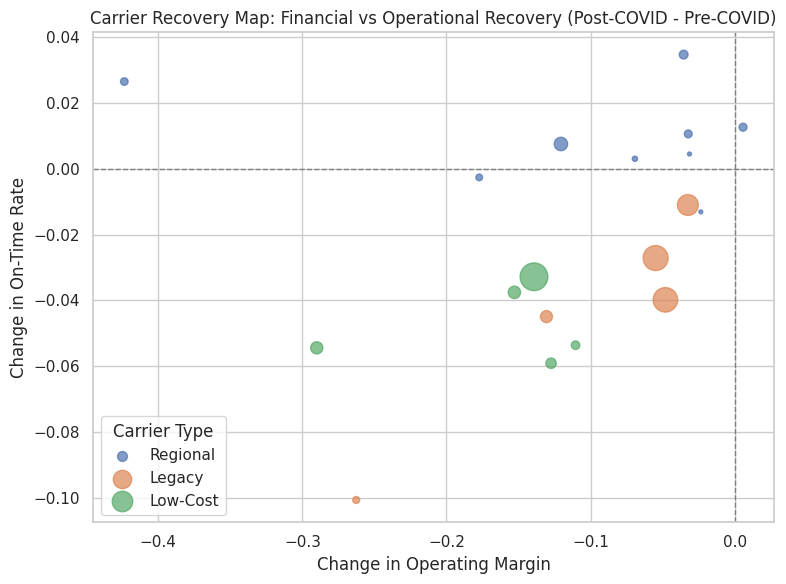

fig_carrier_recovery_map.png saved.


In [46]:
# === Carrier Recovery ===
# - compare how airlines changed pre-COVID to post-COVID
# - based on financial recovery (operating margin) and operational recovery (on-time performance)
recovery_df = agg_df.copy()

summary = (
    recovery_df.groupby(['UNIQUE_CARRIER', 'UNIQUE_CARRIER_NAME', 'carrier_type', 'period'], as_index=False)
    .agg({
        'operating_margin': 'mean',
        'on_time_rate': 'mean',
        'PASSENGERS': 'mean'
    })
)

pivot = summary.pivot_table(
    index=['UNIQUE_CARRIER', 'UNIQUE_CARRIER_NAME', 'carrier_type'],
    columns='period',
    values=['operating_margin', 'on_time_rate', 'PASSENGERS']
)

pivot.columns = ['_'.join(col).strip() for col in pivot.columns]
pivot = pivot.reset_index()

# keep only carriers with both periods
plot_df = pivot.dropna(subset=['operating_margin_Pre-COVID', 'operating_margin_Post-COVID',
                               'on_time_rate_Pre-COVID', 'on_time_rate_Post-COVID']).copy()

plot_df['margin_change'] = plot_df['operating_margin_Post-COVID'] - plot_df['operating_margin_Pre-COVID']
plot_df['ontime_change'] = plot_df['on_time_rate_Post-COVID'] - plot_df['on_time_rate_Pre-COVID']
plot_df['avg_passengers'] = plot_df[['PASSENGERS_Pre-COVID', 'PASSENGERS_Post-COVID']].mean(axis=1)

plt.figure(figsize=(8,6))

for ctype in plot_df['carrier_type'].dropna().unique():
    subset = plot_df[plot_df['carrier_type'] == ctype]
    plt.scatter(
        subset['margin_change'],
        subset['ontime_change'],
        s=subset['avg_passengers'] / 100000,
        alpha=0.7,
        label=ctype
    )

plt.axhline(0, linestyle='--', linewidth=1, color='grey')
plt.axvline(0, linestyle='--', linewidth=1, color='grey')
plt.xlabel('Change in Operating Margin')
plt.ylabel('Change in On-Time Rate')
plt.title('Carrier Recovery Map: Financial vs Operational Recovery (Post-COVID - Pre-COVID)')
plt.legend(title='Carrier Type')

plt.tight_layout()
plt.savefig('fig_carrier_recovery_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig_carrier_recovery_map.png saved.")

# Top-right: improved financially and operationally
# Bottom-right: improved financially but worsened operationally
# Top-left: worsened financially but improved operationally
# Bottom-left: worsened financially and operationally

# Bubble size represents each carrier's average passenger volume
#   across both periods, showing overall operation scale

In [47]:
print("agg_df shape:", agg_df.shape)
print("Duplicate keys:", agg_df['Match Key'].duplicated().sum())

desc_cols = [
    'PASSENGERS','FREIGHT_LBS','MAIL_LBS','DISTANCE_MI','route_count',
    'avg_passengers_per_route','avg_distance_per_route',
    'OP_REVENUES','OP_EXPENSES','NET_INCOME',
    'operating_margin','net_margin',
    'cost_per_passenger','revenue_per_passenger',
    'on_time_rate','cancellation_rate','avg_arr_delay_min'
]

desc_cols = [c for c in desc_cols if c in agg_df.columns]

print("\nMissing Values:\n", agg_df[desc_cols].isna().sum().sort_values(ascending=False))
print("\nSummary Statistics:\n", agg_df[desc_cols].describe().T)

agg_df shape: (4440, 107)
Duplicate keys: 0

Missing Values:
 avg_arr_delay_min           3701
cancellation_rate           3701
on_time_rate                3701
revenue_per_passenger       3213
cost_per_passenger          3213
NET_INCOME                  2615
OP_REVENUES                 2615
net_margin                  2615
OP_EXPENSES                 2615
operating_margin            2615
PASSENGERS                     0
avg_passengers_per_route       0
avg_distance_per_route         0
MAIL_LBS                       0
FREIGHT_LBS                    0
DISTANCE_MI                    0
route_count                    0
dtype: int64

Summary Statistics:
                            count          mean           std           min  \
PASSENGERS                4440.0  1.449912e+06  5.448102e+06  0.000000e+00   
FREIGHT_LBS               4440.0  5.240636e+07  3.058746e+08  0.000000e+00   
MAIL_LBS                  4440.0  2.319127e+06  1.251896e+07  0.000000e+00   
DISTANCE_MI               4440

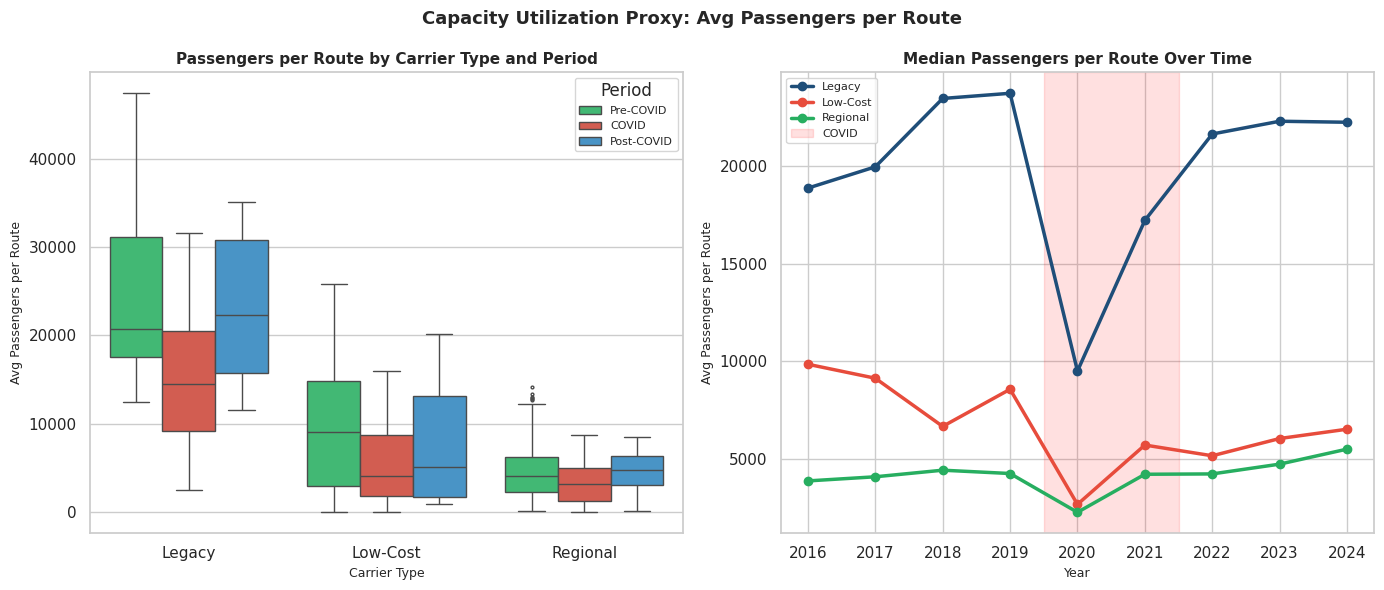

fig_loadfactor.png saved.


In [48]:
# === Capacity Utilization Proxy: Avg Passengers per Route ===
util_types   = ['Legacy', 'Low-Cost', 'Regional']
period_order = ['Pre-COVID', 'COVID', 'Post-COVID']
period_pal   = {'Pre-COVID': '#2ecc71', 'COVID': '#e74c3c', 'Post-COVID': '#3498db'}

util_df = agg_df[
    agg_df['carrier_type'].isin(util_types) &
    agg_df['period'].isin(period_order) &
    agg_df['avg_passengers_per_route'].between(1, 50000)
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Capacity Utilization Proxy: Avg Passengers per Route',
             fontsize=13, fontweight='bold')

# Left: boxplot by carrier type x period
sns.boxplot(
    data=util_df, x='carrier_type', y='avg_passengers_per_route',
    hue='period', order=util_types,
    hue_order=period_order, palette=period_pal,
    ax=axes[0], linewidth=1, fliersize=2
)
axes[0].set_title('Passengers per Route by Carrier Type and Period',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Carrier Type', fontsize=9)
axes[0].set_ylabel('Avg Passengers per Route', fontsize=9)
axes[0].legend(title='Period', fontsize=8)

# Right: yearly trend lines
yearly_util = (
    agg_df[agg_df['carrier_type'].isin(util_types)]
    .groupby(['YEAR', 'carrier_type'])['avg_passengers_per_route']
    .median()
    .reset_index()
)
yearly_util = yearly_util[yearly_util['avg_passengers_per_route'].between(1, 50000)]

for ctype, color in [('Legacy','#1f4e79'),('Low-Cost','#e74c3c'),('Regional','#27ae60')]:
    sub = yearly_util[yearly_util['carrier_type'] == ctype]
    axes[1].plot(sub['YEAR'], sub['avg_passengers_per_route'],
                 label=ctype, color=color, marker='o', linewidth=2.5, markersize=6)

axes[1].axvspan(2019.5, 2021.5, alpha=0.12, color='red', label='COVID')
axes[1].set_title('Median Passengers per Route Over Time',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Year', fontsize=9)
axes[1].set_ylabel('Avg Passengers per Route', fontsize=9)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_loadfactor.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig_loadfactor.png saved.")

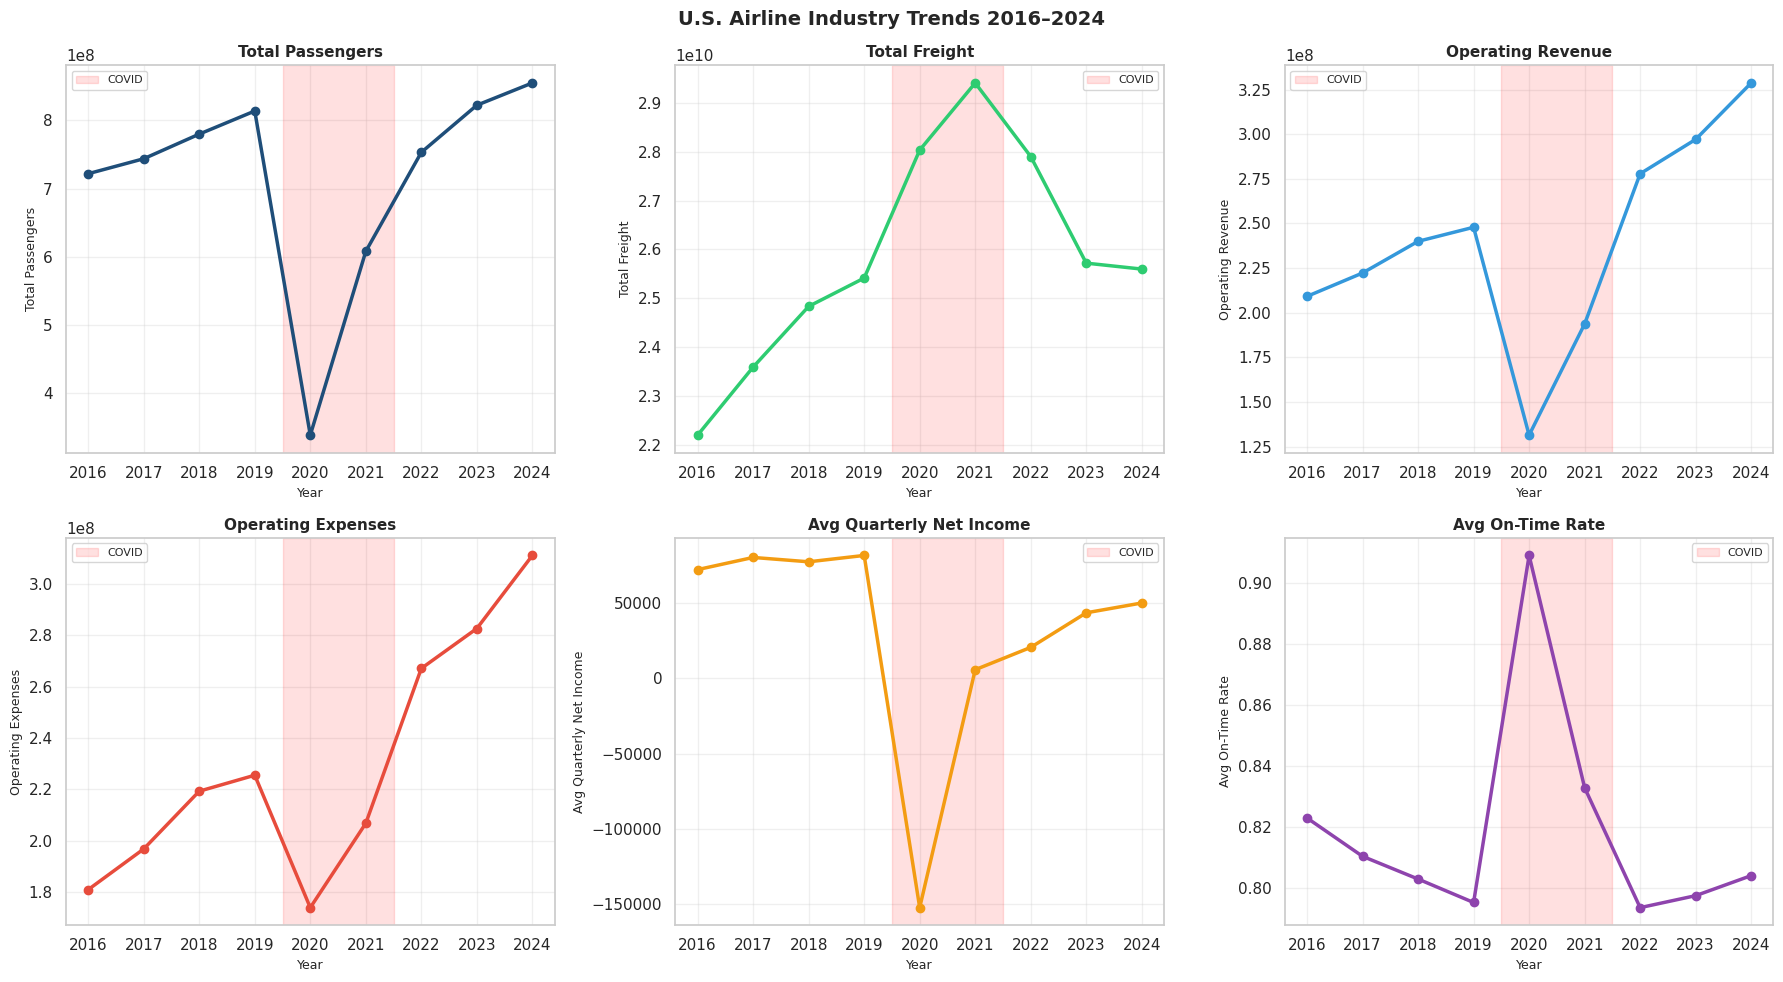

fig_yearly_trends.png saved.


In [49]:
# === Industry Trends Figure ===
sns.set_theme(style='whitegrid')

yearly = agg_df.groupby('YEAR', as_index=False).agg(
    PASSENGERS        = ('PASSENGERS',        'sum'),
    FREIGHT_LBS       = ('FREIGHT_LBS',       'sum'),
    OP_REVENUES       = ('OP_REVENUES',       'sum'),
    OP_EXPENSES       = ('OP_EXPENSES',       'sum'),
    NET_INCOME        = ('NET_INCOME',        'mean'),
    on_time_rate      = ('on_time_rate',      'mean'),
    cancellation_rate = ('cancellation_rate', 'mean'),
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('U.S. Airline Industry Trends 2016–2024',
             fontsize=14, fontweight='bold')

specs = [
    ('PASSENGERS',        'Total Passengers',          '#1f4e79'),
    ('FREIGHT_LBS',       'Total Freight',             '#2ecc71'),
    ('OP_REVENUES',       'Operating Revenue',         '#3498db'),
    ('OP_EXPENSES',       'Operating Expenses',        '#e74c3c'),
    ('NET_INCOME',        'Avg Quarterly Net Income',  '#f39c12'),
    ('on_time_rate',      'Avg On-Time Rate',          '#8e44ad'),
]

for ax, (col, label, color) in zip(axes.flat, specs):
    if col not in yearly.columns:
        ax.set_visible(False)
        continue
    ax.plot(yearly['YEAR'], yearly[col],
            marker='o', color=color, linewidth=2.5, markersize=6)
    ax.axvspan(2019.5, 2021.5, alpha=0.12, color='red', label='COVID')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel(label, fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_yearly_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig_yearly_trends.png saved.")

In [50]:
# to compare to values on BTS
#   https://transtats.bts.gov/Fields.asp?gnoyr_VQ=FMI
#   NetIncome --> Analysis
check = agg_df.groupby('YEAR').agg(
    net_income_sum=('NET_INCOME',   'sum'),
    net_income_mean=('NET_INCOME',  'mean'),
    op_revenues_sum=('OP_REVENUES', 'sum'),
    op_expenses_sum=('OP_EXPENSES', 'sum'),
)

print(check.to_string(float_format='{:,.2f}'.format))

      net_income_sum  net_income_mean  op_revenues_sum  op_expenses_sum
YEAR                                                                   
2016   15,616,915.58        71,967.35   209,153,032.30   180,940,410.96
2017   16,807,145.28        80,034.03   222,245,764.40   196,797,158.07
2018   15,429,110.87        77,145.55   239,991,670.51   219,301,265.17
2019   16,434,565.05        81,359.23   247,865,686.36   225,526,153.62
2020  -30,899,393.35      -152,213.76   131,398,412.96   173,925,084.33
2021    1,138,727.78         5,582.00   193,692,043.77   206,798,864.54
2022    3,914,857.13        20,389.88   277,858,975.24   267,144,623.16
2023    8,793,696.77        43,318.70   297,108,764.83   282,699,193.27
2024    9,667,093.60        49,830.38   328,730,932.92   311,171,467.78


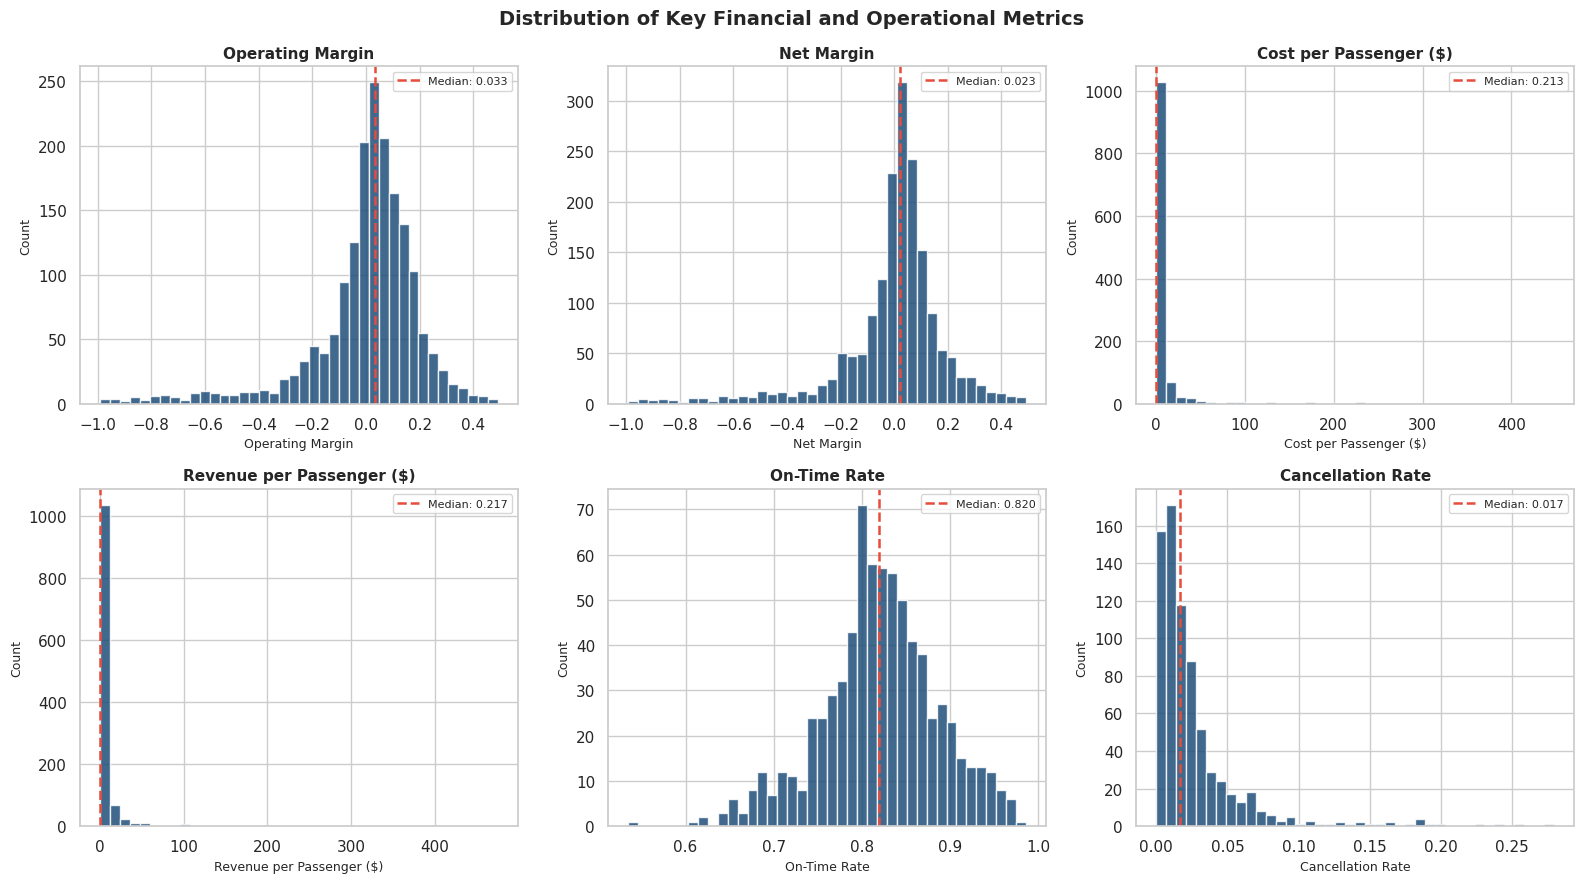

fig_distributions.png saved.


In [51]:
# === Distribution of Key Financial and Operational Metrics ===
COLORS = {
    'Legacy':   '#1f4e79',
    'Low-Cost': '#e74c3c',
    'Cargo':    '#f39c12',
    'Regional': '#27ae60',
    'Other':    '#95a5a6'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribution of Key Financial and Operational Metrics',
             fontsize=14, fontweight='bold')

dist_specs = [
    ('operating_margin',      'Operating Margin',             -1.0,  0.5),
    ('net_margin',            'Net Margin',                   -1.0,  0.5),
    ('cost_per_passenger',    'Cost per Passenger ($)',         0.0, 500.0),
    ('revenue_per_passenger', 'Revenue per Passenger ($)',      0.0, 500.0),
    ('on_time_rate',          'On-Time Rate',                   0.5,  1.0),
    ('cancellation_rate',     'Cancellation Rate',              0.0,  0.3),
]

for ax, (col, label, lo, hi) in zip(axes.flat, dist_specs):
    if col not in agg_df.columns:
        ax.set_visible(False)
        continue
    data = agg_df[col].dropna()
    data = data[(data >= lo) & (data <= hi)]
    ax.hist(data, bins=40, color='#1f4e79', edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='#e74c3c', linestyle='--',
               linewidth=1.8, label=f'Median: {data.median():.3f}')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig_distributions.png saved.")

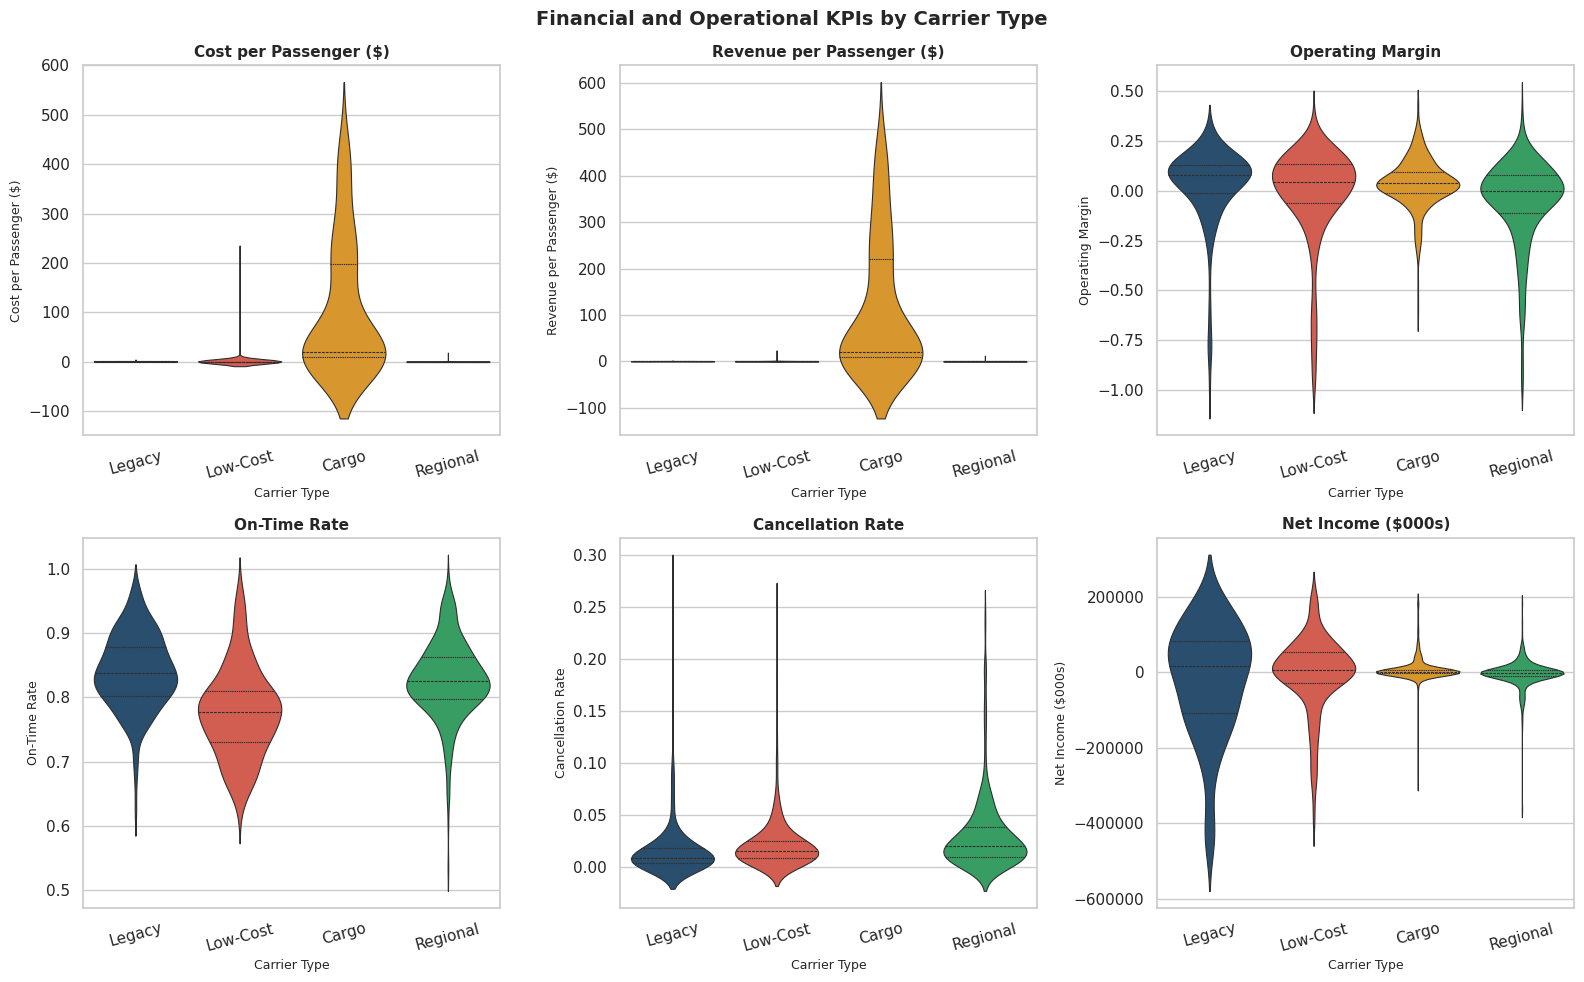

fig_carrier_kpis.png saved.


In [52]:
# === Financial and Operational KPIs by Carrier Type ===
plot_types = ['Legacy','Low-Cost','Cargo','Regional']
plot_df2   = agg_df[agg_df['carrier_type'].isin(plot_types)].copy()
palette2   = [COLORS[t] for t in plot_types]

compare_specs = [
    ('cost_per_passenger',    'Cost per Passenger ($)',    0,   500),
    ('revenue_per_passenger', 'Revenue per Passenger ($)', 0,   500),
    ('operating_margin',      'Operating Margin',         -1,   0.5),
    ('on_time_rate',          'On-Time Rate',              0.5, 1.0),
    ('cancellation_rate',     'Cancellation Rate',         0,   0.3),
    ('NET_INCOME',            'Net Income ($000s)',       -5e5, 2e5),
]
compare_specs = [(c,l,lo,hi) for c,l,lo,hi in compare_specs
                 if c in plot_df2.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Financial and Operational KPIs by Carrier Type',
             fontsize=14, fontweight='bold')

for ax, (col, label, lo, hi) in zip(axes.flat, compare_specs):
    d = plot_df2[
        (plot_df2[col] >= lo) & (plot_df2[col] <= hi)
    ].copy()
    sns.violinplot(data=d, x='carrier_type', y=col,
                   order=plot_types,
                   hue='carrier_type',
                   palette=dict(zip(plot_types, palette2)),
                   inner='quartile', ax=ax, linewidth=0.8,
                   legend=False)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Carrier Type', fontsize=9)
    ax.set_ylabel(label, fontsize=9)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('fig_carrier_kpis.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig_carrier_kpis.png saved.")

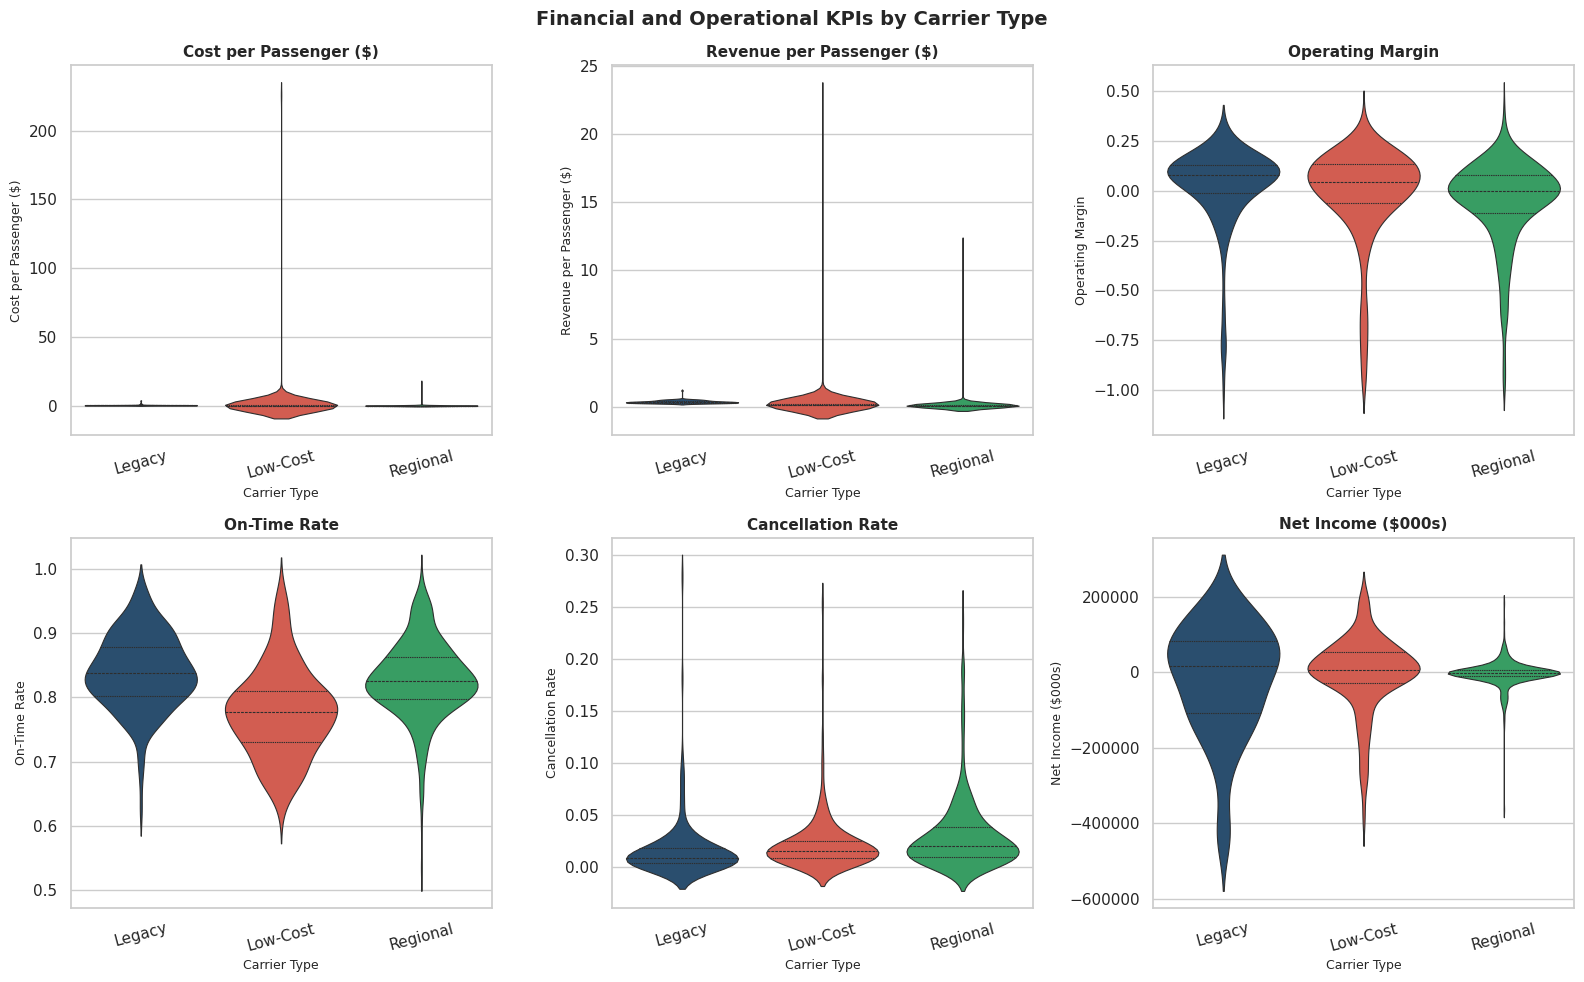

fig_carrier_kpis_nocargo.png saved.


In [53]:
# === Financial and Operational KPIs by Carrier Type ===
# - excluding cargo due to inflated per passenger results
plot_types = ['Legacy','Low-Cost','Regional']
plot_df2   = agg_df[agg_df['carrier_type'].isin(plot_types)].copy()
palette2   = [COLORS[t] for t in plot_types]

compare_specs = [
    ('cost_per_passenger',    'Cost per Passenger ($)',    0,   500),
    ('revenue_per_passenger', 'Revenue per Passenger ($)', 0,   500),
    ('operating_margin',      'Operating Margin',         -1,   0.5),
    ('on_time_rate',          'On-Time Rate',              0.5, 1.0),
    ('cancellation_rate',     'Cancellation Rate',         0,   0.3),
    ('NET_INCOME',            'Net Income ($000s)',       -5e5, 2e5),
]
compare_specs = [(c,l,lo,hi) for c,l,lo,hi in compare_specs
                 if c in plot_df2.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Financial and Operational KPIs by Carrier Type',
             fontsize=14, fontweight='bold')

for ax, (col, label, lo, hi) in zip(axes.flat, compare_specs):
    d = plot_df2[
        (plot_df2[col] >= lo) & (plot_df2[col] <= hi)
    ].copy()
    sns.violinplot(data=d, x='carrier_type', y=col,
                   order=plot_types,
                   hue='carrier_type',
                   palette=dict(zip(plot_types, palette2)),
                   inner='quartile', ax=ax, linewidth=0.8,
                   legend=False)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Carrier Type', fontsize=9)
    ax.set_ylabel(label, fontsize=9)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('fig_carrier_kpis_nocargo.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig_carrier_kpis_nocargo.png saved.")

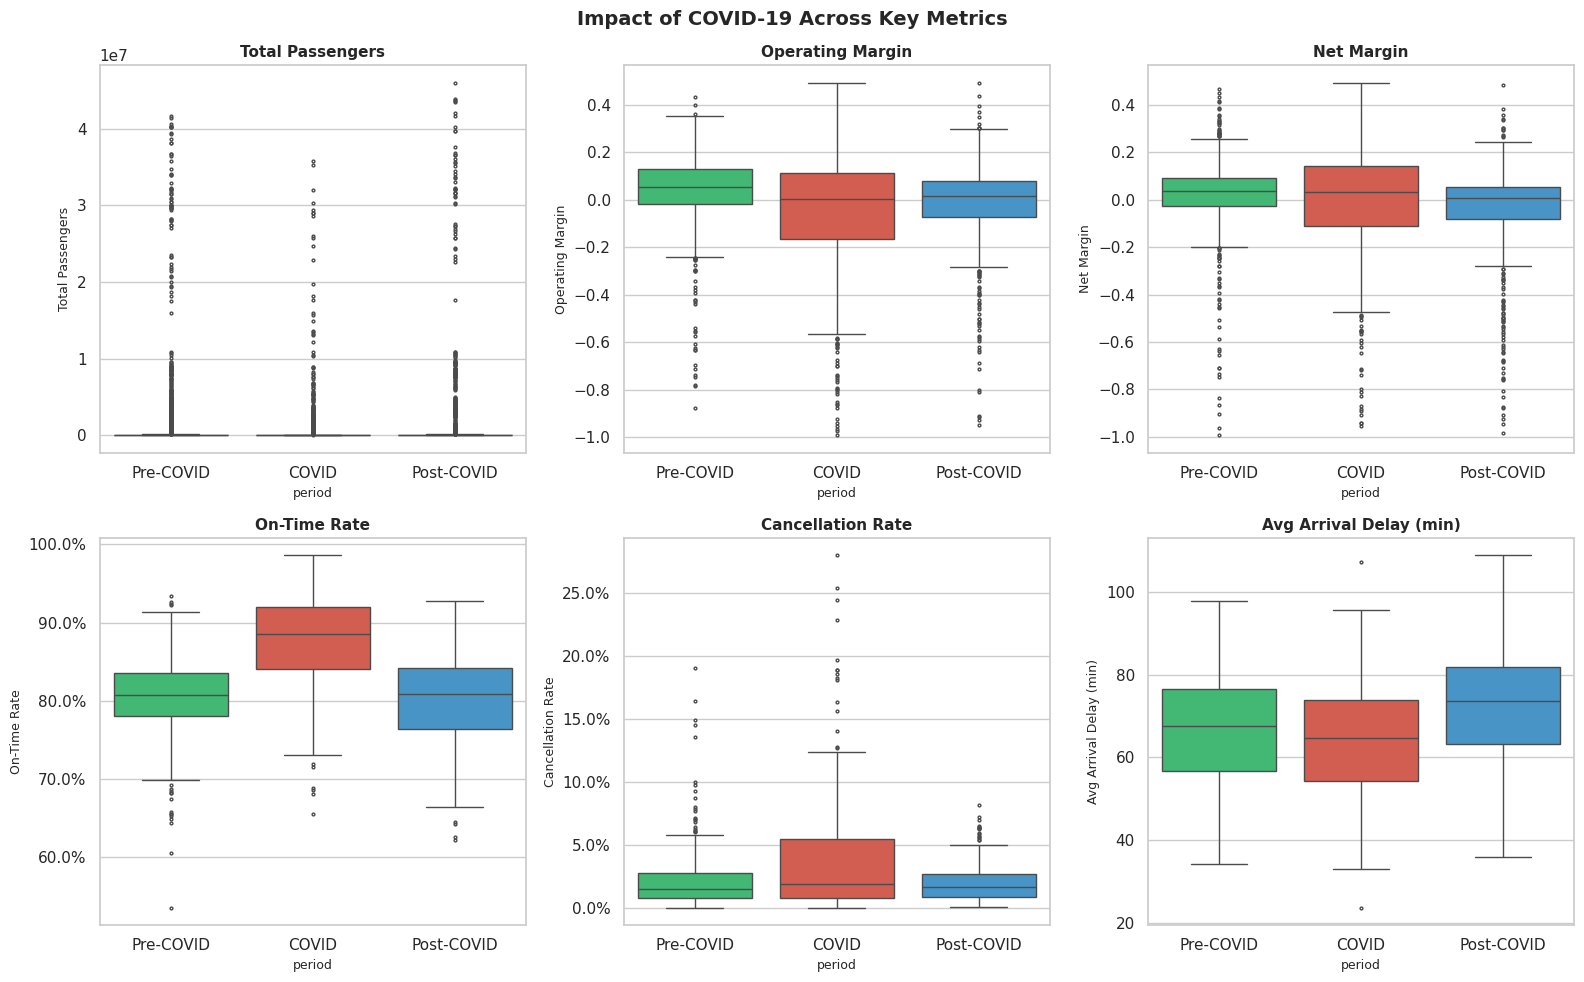

fig_covid_periods.png saved.


In [54]:
# === Impact of COVID-19 Across Key Metrics ===
period_order = ['Pre-COVID','COVID','Post-COVID']
period_pal   = {'Pre-COVID':'#2ecc71','COVID':'#e74c3c','Post-COVID':'#3498db'}
period_df2   = agg_df[agg_df['period'].isin(period_order)].copy()

period_specs = [
    ('PASSENGERS',        'Total Passengers',        0,    5e7),
    ('operating_margin',  'Operating Margin',       -1,    0.5),
    ('net_margin',        'Net Margin',             -1,    0.5),
    ('on_time_rate',      'On-Time Rate',            0.5,  1.0),
    ('cancellation_rate', 'Cancellation Rate',       0,    0.3),
    ('avg_arr_delay_min', 'Avg Arrival Delay (min)', 0,  120.0),
]
period_specs = [(c,l,lo,hi) for c,l,lo,hi in period_specs
                if c in period_df2.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Impact of COVID-19 Across Key Metrics',
             fontsize=14, fontweight='bold')

for ax, (col, label, lo, hi) in zip(axes.flat, period_specs):
    d = period_df2[
        (period_df2[col] >= lo) & (period_df2[col] <= hi)
    ].copy()
    sns.boxplot(data=d, x='period', y=col,
                order=period_order,
                hue='period',
                palette=period_pal,
                ax=ax, fliersize=2, linewidth=1,
                legend=False)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('period', fontsize=9)
    ax.set_ylabel(label, fontsize=9)
    if col in ('on_time_rate','cancellation_rate'):
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.savefig('fig_covid_periods.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig_covid_periods.png saved.")

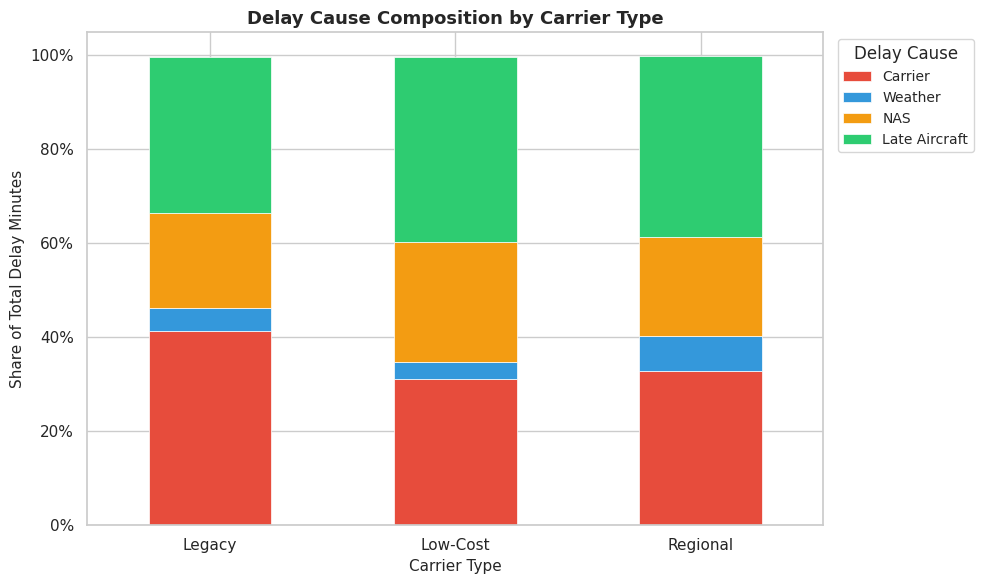

fig_delay_causes.png saved.

Delay means:
              Carrier  Weather    NAS  Late Aircraft
carrier_type                                        
Legacy          0.413    0.048  0.202          0.333
Low-Cost        0.312    0.036  0.255          0.394
Regional        0.329    0.074  0.210          0.387


In [55]:
# === Delay Cause Composition by Carrier Type ===
delay_cols = ['pct_carrier_delay', 'pct_weather_delay',
              'pct_nas_delay',     'pct_late_ac_delay']

if all(c in agg_df.columns for c in delay_cols):
    delay_df    = agg_df.dropna(subset=delay_cols).copy()
    avail_types = [t for t in plot_types
                   if t in delay_df['carrier_type'].values]

    if avail_types:
        delay_means = (
            delay_df.groupby('carrier_type')[delay_cols]
                    .mean()
                    .loc[avail_types]
        )
        delay_means.columns = ['Carrier','Weather','NAS','Late Aircraft']

        fig, ax = plt.subplots(figsize=(10, 6))
        delay_means.plot(kind='bar', stacked=True, ax=ax,
                         color=['#e74c3c','#3498db','#f39c12','#2ecc71'],
                         edgecolor='white', linewidth=0.5)
        ax.set_title('Delay Cause Composition by Carrier Type',
                     fontsize=13, fontweight='bold')
        ax.set_xlabel('Carrier Type', fontsize=11)
        ax.set_ylabel('Share of Total Delay Minutes', fontsize=11)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        ax.legend(title='Delay Cause', bbox_to_anchor=(1.01,1),
                  loc='upper left', fontsize=10)
        ax.tick_params(axis='x', rotation=0)
        plt.tight_layout()
        plt.savefig('fig_delay_causes.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("fig_delay_causes.png saved.")
        print("\nDelay means:")
        print(delay_means.round(3))
    else:
        print("No named carrier types in delay data.")
else:
    print("Delay columns missing.")

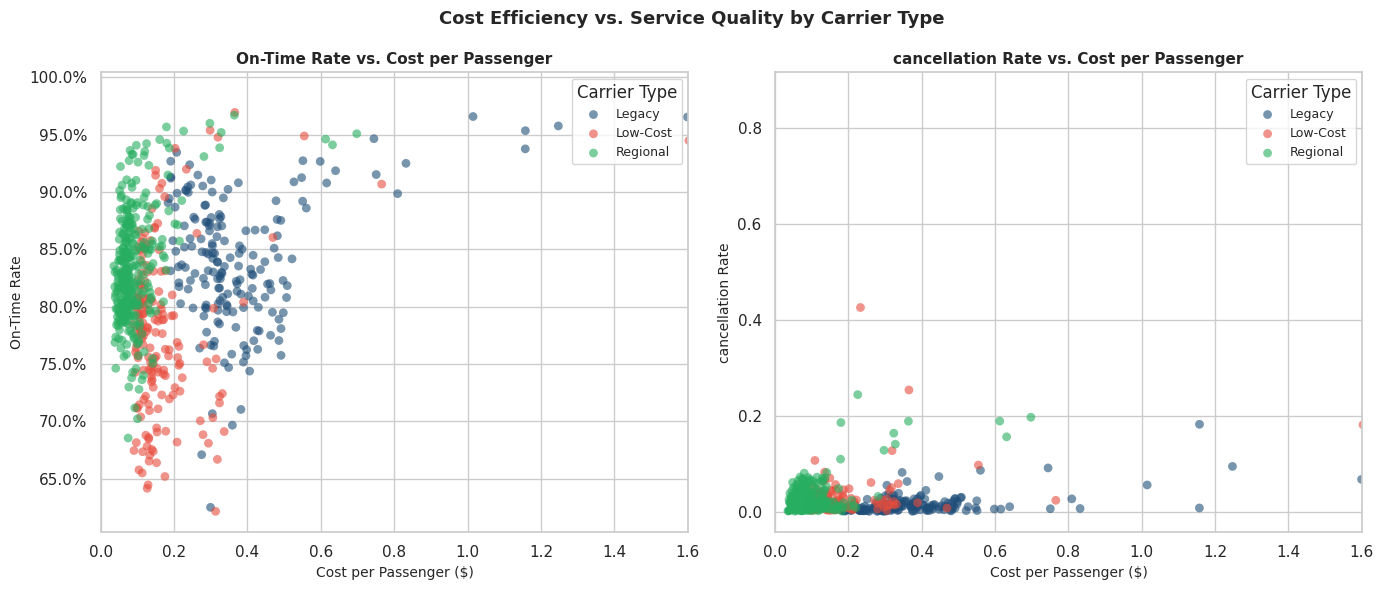

fig_cost_vs_service.png saved.


In [56]:
# === Cost Efficiency vs. Service Quality by Carrier Type ===
if 'on_time_rate' in agg_df.columns:
    scatter_df = agg_df[
        agg_df['carrier_type'].isin(plot_types)
    ].dropna(subset=['cost_per_passenger','on_time_rate',
                     'cancellation_rate'])
    scatter_df = scatter_df[
        (scatter_df['cost_per_passenger'] > 0) &
        (scatter_df['cost_per_passenger'] < 500)
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Cost Efficiency vs. Service Quality by Carrier Type',
                 fontsize=13, fontweight='bold')

    for ax, (y_col, y_label) in zip(axes, [
        ('on_time_rate',      'On-Time Rate'),
        ('cancellation_rate', 'cancellation Rate')
    ]):
        for ctype in plot_types:
            sub = scatter_df[scatter_df['carrier_type'] == ctype]
            ax.scatter(sub['cost_per_passenger'], sub[y_col],
                       label=ctype, color=COLORS[ctype],
                       alpha=0.6, s=40, edgecolors='none')

        ax.set_xlabel('Cost per Passenger ($)', fontsize=10)
        ax.set_ylabel(y_label, fontsize=10)
        ax.set_title(f'{y_label} vs. Cost per Passenger',
                     fontsize=11, fontweight='bold')
        ax.legend(fontsize=9, title='Carrier Type')

        # Exclude extreme outliers
        ax.set_xlim(0, scatter_df['cost_per_passenger'].quantile(0.995))

        if y_col == 'on_time_rate':
            ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    plt.tight_layout()
    plt.savefig('fig_cost_vs_service.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("fig_cost_vs_service.png saved.")

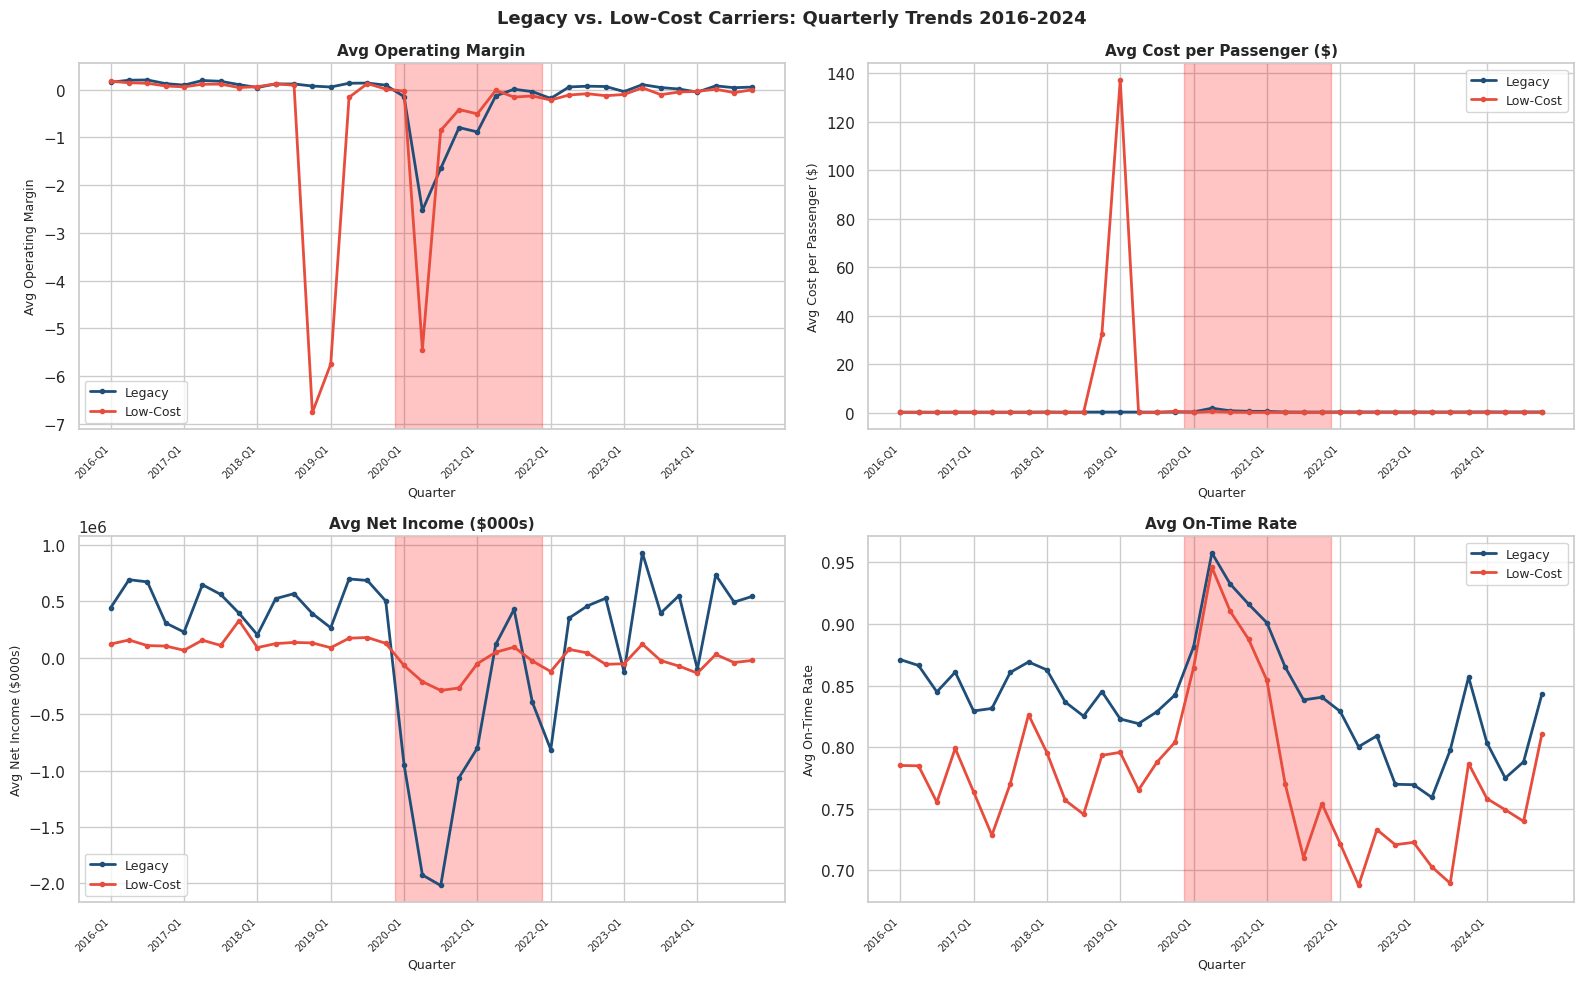

fig_quarterly_trends.png saved.


In [57]:
# === Legacy vs. Low-Cost Carriers: Quarterly Trends ===
trend_df = agg_df[
    agg_df['carrier_type'].isin(['Legacy', 'Low-Cost'])
].copy().dropna(subset=['YEAR', 'QUARTER'])

trend_df['YEAR']    = trend_df['YEAR'].astype(int)
trend_df['QUARTER'] = trend_df['QUARTER'].astype(int)

quarterly = (
    trend_df.groupby(['YEAR', 'QUARTER', 'carrier_type'])
    .agg(
        Avg_Operating_Margin = ('operating_margin',   'mean'),
        Avg_Cost_per_Pax     = ('cost_per_passenger', 'mean'),
        Avg_Net_Income       = ('NET_INCOME',   'mean'),
        Avg_OnTime           = ('on_time_rate',       'mean'),
    )
    .reset_index()
    .sort_values(['YEAR', 'QUARTER'])
)

quarterly['period_label'] = (
    quarterly['YEAR'].astype(str) + '-Q' +
    quarterly['QUARTER'].astype(str)
)

all_labels     = quarterly['period_label'].unique()
tick_positions = list(range(0, len(all_labels), 4))
tick_labels    = all_labels[tick_positions]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Legacy vs. Low-Cost Carriers: Quarterly Trends 2016-2024',
             fontsize=13, fontweight='bold')

metrics = [
    ('Avg_Operating_Margin', 'Avg Operating Margin'),
    ('Avg_Cost_per_Pax',     'Avg Cost per Passenger ($)'),
    ('Avg_Net_Income',       'Avg Net Income ($000s)'),
    ('Avg_OnTime',           'Avg On-Time Rate'),
]

for ax, (col, label) in zip(axes.flat, metrics):
    for ctype, color in [('Legacy', '#1f4e79'), ('Low-Cost', '#e74c3c')]:
        sub = quarterly[quarterly['carrier_type'] == ctype].reset_index(drop=True)
        if len(sub) == 0:
            continue
        ax.plot(sub['period_label'], sub[col],
                label=ctype, color=color, linewidth=2, marker='o', markersize=3)
        covid_mask = sub['YEAR'].isin([2020, 2021])
        covid_idx  = sub.index[covid_mask]
        if len(covid_idx):
            ax.axvspan(covid_idx.min() - 0.5, covid_idx.max() + 0.5,
                       alpha=0.12, color='red', label='_COVID')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Quarter', fontsize=9)
    ax.set_ylabel(label, fontsize=9)
    ax.legend(fontsize=9)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.savefig('fig_quarterly_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig_quarterly_trends.png saved.")

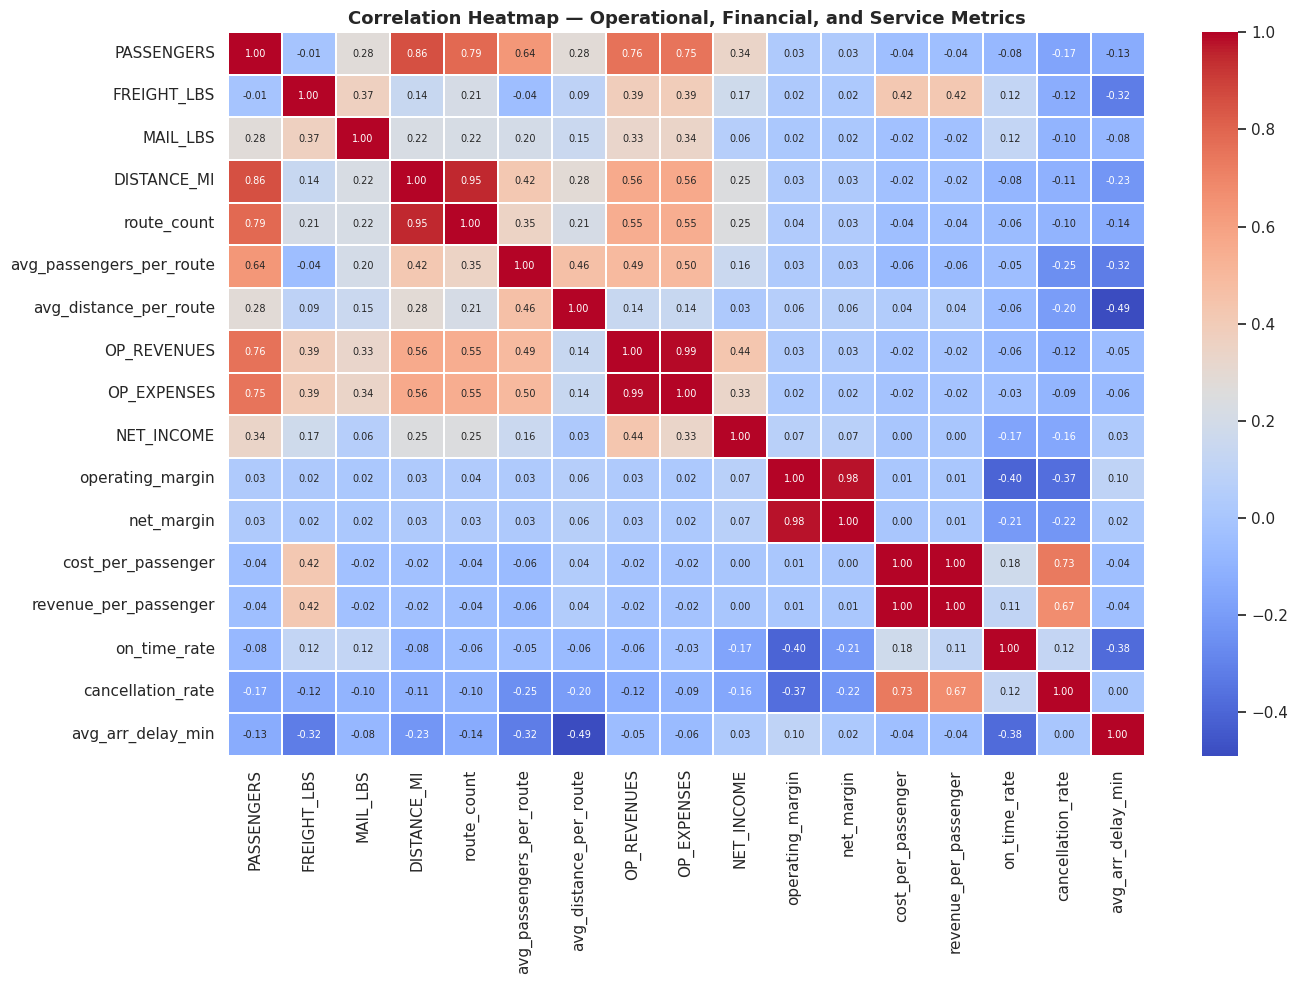

fig_correlation_heatmap.png saved.


In [58]:
# === Correlation Heatmap - Operational, Financial, and Service Metrics ===
heatmap_cols = [
    'PASSENGERS','FREIGHT_LBS','MAIL_LBS','DISTANCE_MI','route_count',
    'avg_passengers_per_route','avg_distance_per_route',
    'OP_REVENUES','OP_EXPENSES','NET_INCOME',
    'operating_margin','net_margin',
    'cost_per_passenger','revenue_per_passenger',
    'on_time_rate','cancellation_rate','avg_arr_delay_min'
]

heatmap_cols = [c for c in heatmap_cols if c in agg_df.columns]
corr_df = agg_df[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.3, ax=ax, annot_kws={'size':7})
ax.set_title(
    'Correlation Heatmap — Operational, Financial, and Service Metrics',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig_correlation_heatmap.png saved.")

In [59]:
carrier_summary = (
    agg_df[agg_df['carrier_type'].isin(plot_types)]
    .groupby(['UNIQUE_CARRIER','carrier_type'])
    .agg(
        Quarters         = ('NET_INCOME',         'count'),
        Avg_Net_Income   = ('NET_INCOME',         'mean'),
        Avg_Op_Margin    = ('operating_margin',   'mean'),
        Avg_Cost_per_Pax = ('cost_per_passenger', 'mean'),
        Avg_OnTime       = ('on_time_rate',       'mean'),
        Avg_Cancel       = ('cancellation_rate',  'mean'),
        Total_Passengers = ('PASSENGERS',         'sum'),
    )
    .round(3)
    .reset_index()
    .sort_values('Avg_Op_Margin', ascending=False)
)
print(carrier_summary.to_string(index=False))

UNIQUE_CARRIER carrier_type  Quarters  Avg_Net_Income  Avg_Op_Margin  Avg_Cost_per_Pax  Avg_OnTime  Avg_Cancel  Total_Passengers
            S5     Regional         4      -83860.802          0.108             0.090         NaN         NaN           4356393
            YX     Regional        36       18344.271          0.088             0.080       0.854       0.032         138418137
            VX     Low-Cost         8       12706.651          0.086             0.188       0.752       0.014          18077822
            QX     Regional        36        5554.417          0.048             0.074       0.858       0.020          51356065
            G4     Low-Cost        36       38777.860          0.044             0.117       0.767       0.035         125960123
            YV     Regional        36       -6556.790          0.035             0.066       0.812       0.032          83947691
            SY     Low-Cost        36        9262.607          0.026             0.228         Na

## ML

In [60]:
# === Random Forest Regressor ===

# Remove rows without reported net income
model_df = agg_df.dropna(subset=['NET_INCOME']).copy()
print("Model rows:", model_df.shape[0])

features_clean = [
    'PASSENGERS','FREIGHT_LBS','MAIL_LBS','DISTANCE_MI',
    'route_count','avg_passengers_per_route',
    'avg_distance_per_route','freight_ratio','mail_ratio',
    'network_size','FLYING_OPS','MAINTENANCE',
    'PAX_SERVICE','AIRCFT_SERVICES','GENERAL_ADMIN',
    'DEPREC_AMORT', 'OP_REVENUES','OP_EXPENSES',
    'TRANS_REVENUE','cost_per_passenger','revenue_per_passenger',
    'on_time_rate','cancellation_rate','avg_arr_delay_min'
]
features_clean = [c for c in features_clean if c in model_df.columns]

X = model_df[features_clean].fillna(0)
y = model_df['NET_INCOME']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
preds = rf.predict(X_test)

print("R²:  ", round(r2_score(y_test, preds), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, preds)), 2))

Model rows: 1825
R²:   0.7778
RMSE: 187523.09


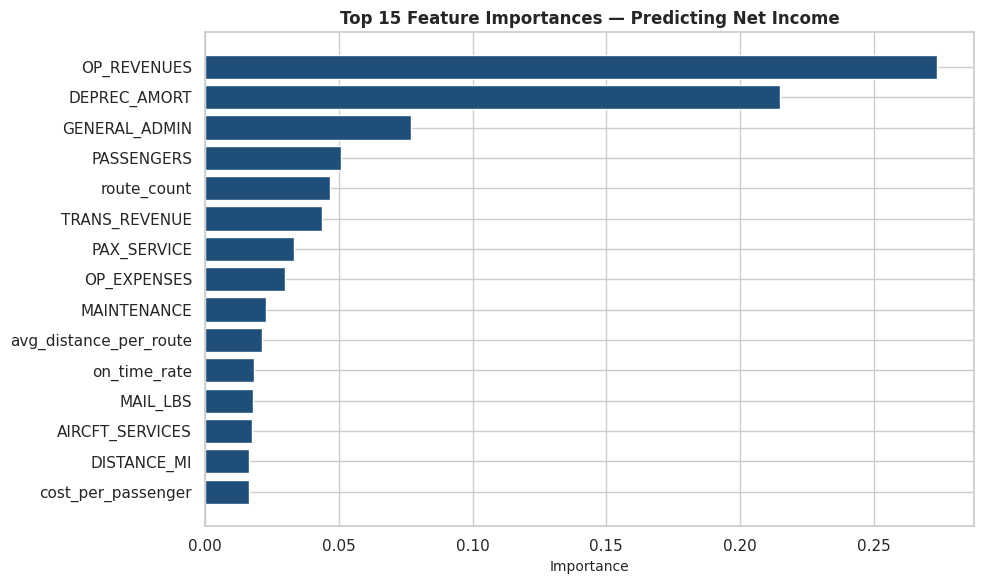

fig_feature_importance.png saved.


In [61]:
# === Feature Importance - Predicting Net Income ===
imp_df = pd.DataFrame({
    'Feature':    features_clean,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1],
        color='#1f4e79', edgecolor='white')
ax.set_title('Top 15 Feature Importances — Predicting Net Income',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance', fontsize=10)
plt.tight_layout()
plt.savefig('fig_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig_feature_importance.png saved.")

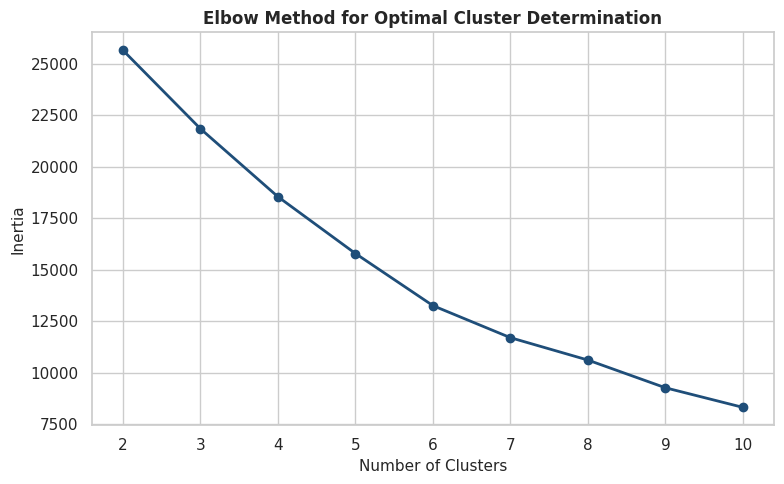

fig_elbow.png saved.


In [62]:
# === Elbow Method for Optimal Cluster Determination ===
cluster_features = [
    'PASSENGERS','FREIGHT_LBS','MAIL_LBS','DISTANCE_MI','route_count',
    'avg_passengers_per_route','avg_distance_per_route',
    'freight_ratio','mail_ratio','network_size',
    'OP_REVENUES','OP_EXPENSES','operating_margin','net_margin',
    'cost_per_passenger','revenue_per_passenger',
    'on_time_rate','cancellation_rate'
]
cluster_features = [c for c in cluster_features if c in model_df.columns]

X_cluster = model_df[cluster_features].fillna(0)
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_cluster)

inertia = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, inertia, marker='o', color='#1f4e79', linewidth=2)
ax.set_xlabel('Number of Clusters', fontsize=11)
ax.set_ylabel('Inertia', fontsize=11)
ax.set_title('Elbow Method for Optimal Cluster Determination',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig_elbow.png saved.")

In [63]:
# === k-Means Model ===
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
model_df = model_df.copy()
model_df['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_profile = (
    model_df.groupby('Cluster')[[
        'PASSENGERS','OP_REVENUES','OP_EXPENSES',
        'operating_margin','cost_per_passenger',
        'NET_INCOME','on_time_rate','cancellation_rate'
    ]].mean().round(3)
)
print("Cluster profiles:")
print(cluster_profile.to_string())
print("\nCarrier type distribution by cluster:")
print(pd.crosstab(model_df['Cluster'], model_df['carrier_type']))

Cluster profiles:
           PASSENGERS  OP_REVENUES  OP_EXPENSES  operating_margin  cost_per_passenger  NET_INCOME  on_time_rate  cancellation_rate
Cluster                                                                                                                           
0        2.310843e+07  9509711.950  8957087.340             0.014               0.327  396939.340         0.823              0.017
1        1.413037e+06   293060.661   301077.245            -0.040             197.269   -7734.202         0.821              0.027
2        1.667000e+00       62.933     2008.810           -38.673             593.191   -1848.693           NaN                NaN
3        3.400000e+00   527979.696   487814.736             0.064          118143.051   28687.824           NaN                NaN

Carrier type distribution by cluster:
carrier_type  Cargo  Legacy  Low-Cost  Other  Regional
Cluster                                               
0                38     101        36      0   

=== Cluster Profile (means) ===
         operating_margin  net_margin  cost_per_passenger  revenue_per_passenger  on_time_rate  cancellation_rate  avg_arr_delay_min  route_count    PASSENGERS  n_obs
Cluster                                                                                                                                                               
0                   0.014       0.023               0.327                  0.337         0.823              0.017             64.102     1877.749  2.310843e+07    175
1                  -0.040      -0.034             197.269                215.403         0.821              0.027             68.854      304.139  1.413037e+06   1642
2                 -38.673     -38.013             593.191                 13.755           NaN                NaN                NaN        2.667  1.667000e+00      3
3                   0.064       0.045          118143.051             126483.072           NaN                NaN                NaN 

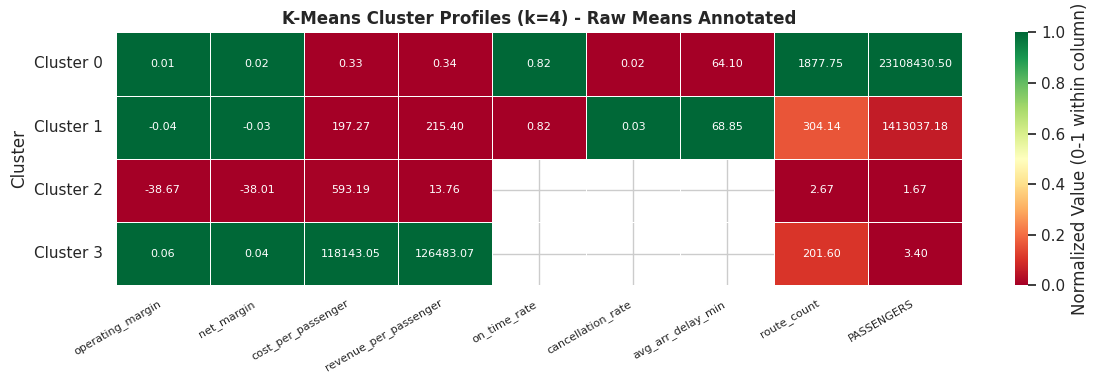

fig_cluster_profiles.png saved.


In [64]:
# === Cluster Profiling + Heatmap ===
N_CLUSTERS = 4

km_final = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
model_df['Cluster'] = km_final.fit_predict(X_scaled)

profile_cols = [
    'load_factor', 'operating_margin', 'net_margin',
    'cost_per_passenger', 'revenue_per_passenger',
    'on_time_rate', 'cancellation_rate',
    'avg_arr_delay_min', 'route_count', 'PASSENGERS'
]
profile_cols = [c for c in profile_cols if c in model_df.columns]

cluster_profile = (
    model_df.groupby('Cluster')[profile_cols].mean().round(3)
)
cluster_profile['n_obs'] = model_df['Cluster'].value_counts().sort_index()

ct_comp = (
    model_df.groupby('Cluster')['carrier_type']
    .value_counts(normalize=True).mul(100).round(1)
    .unstack(fill_value=0.0)
)
period_comp = (
    model_df.groupby('Cluster')['period']
    .value_counts(normalize=True).mul(100).round(1)
    .unstack(fill_value=0.0)
)

print("=== Cluster Profile (means) ===")
print(cluster_profile.to_string())
print("\n=== Carrier Type Composition (%) ===")
print(ct_comp.to_string())
print("\n=== Period Composition (%) ===")
print(period_comp.to_string())

cluster_labels = {
    0: 'Cluster 0',
    1: 'Cluster 1',
    2: 'Cluster 2',
    3: 'Cluster 3',
}
model_df['Cluster_Label'] = model_df['Cluster'].map(cluster_labels)

profile_plot = cluster_profile[profile_cols].copy()
profile_norm = (
    (profile_plot - profile_plot.min()) /
    (profile_plot.max() - profile_plot.min() + 1e-9)
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    profile_norm,
    annot=profile_plot.values, fmt='.2f',
    cmap='RdYlGn', ax=ax, linewidths=0.5,
    cbar_kws={'label': 'Normalized Value (0-1 within column)'},
    annot_kws={'size': 8}
)
ax.set_title('K-Means Cluster Profiles (k=4) - Raw Means Annotated',
             fontsize=12, fontweight='bold')
ax.set_yticklabels(
    [cluster_labels[i] for i in range(N_CLUSTERS)], rotation=0
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('fig_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig_cluster_profiles.png saved.")